# NUS Curriculum & Job Alignment Framework

This notebook implements a scalable, validated framework for assessing alignment between NUS degree programmes (constructed from `modules.csv`) and MyCareersFuture job advertisements.

**Objective:** Provide MOE with a credible, systematic framework for curriculum-job alignment analysis at the degree level.

**Sections:**
0. Setup
1. Data Loading & Preprocessing
2. Degree Profile Construction
3. Semantic Embedding
4. Baseline Cosine Similarity Retrieval
5. Job-Skill Coverage Score (Hybrid Alignment)
6. Job Clustering (Scalability Layer)
7. Evaluation Framework
8. Results Summary & Interpretation

---
## Section 0: Setup

In [1]:
import os
import re
import json
import time
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from bs4 import BeautifulSoup

warnings.filterwarnings('ignore')

JOB_CORPUS_VERSION = 'targeted_dedup_v2'
SEMANTIC_RETRIEVAL_VERSION = 'module_top5_job120_v1'
JOB_DESC_WORD_LIMIT = 120
DEGREE_MODULE_TOP_K = 5
SKILL_SIGNAL_VERSION = 'job_skill_coverage_v1'

# ── Paths ──────────────────────────────────────────────────────────────────────
if Path.cwd().name == 'notebooks':
    REPO_ROOT = Path('..').resolve()
else:
    REPO_ROOT = Path('.').resolve()
DATA_DIR       = REPO_ROOT / 'data'
JOBS_DIR       = DATA_DIR  / 'MyCareersFutureData'
MODULES_CSV    = DATA_DIR  / 'modules.csv'
CACHE_DIR      = REPO_ROOT / 'notebooks' / 'cache'
EVAL_DIR       = REPO_ROOT / 'notebooks' / 'evaluation'

CACHE_DIR.mkdir(exist_ok=True)
EVAL_DIR.mkdir(exist_ok=True)

def listify_text_values(value) -> list[str]:
    if value is None:
        return []
    if isinstance(value, str):
        return [part.strip() for part in value.split(',') if part.strip()]
    if isinstance(value, (list, tuple, set, np.ndarray, pd.Series)):
        return [str(item).strip() for item in value if pd.notna(item) and str(item).strip()]
    return []

def truncate_words(text: str, max_words: int) -> str:
    words = str(text or '').split()
    return ' '.join(words[:max_words])

def build_structured_job_text(row: pd.Series, max_desc_words: int = JOB_DESC_WORD_LIMIT) -> str:
    parts = [str(row.get('title', '') or '').strip()]

    categories = listify_text_values(row.get('categories', []))
    skills = listify_text_values(row.get('skills', []))

    if categories:
        parts.append(f"Categories: {', '.join(categories)}.")
    if skills:
        parts.append(f"Skills: {', '.join(skills)}.")

    description = truncate_words(row.get('description_clean', ''), max_desc_words)
    if description:
        parts.append(description)

    return ' '.join(part for part in parts if part).strip()

def build_module_text(row: pd.Series) -> str:
    parts = [f"{row['moduleCode']}. {row['description_clean']}"]

    if row.get('description_skills', ''):
        parts.append(f"Skills: {row['description_skills']}.")

    return ' '.join(parts).strip()

def aggregate_top_k_similarity(score_matrix: np.ndarray, top_k: int) -> np.ndarray:
    if score_matrix.ndim != 2:
        raise ValueError('score_matrix must be a 2D array.')
    if score_matrix.shape[0] == 0:
        return np.zeros(score_matrix.shape[1], dtype=np.float32)

    k = min(top_k, score_matrix.shape[0])
    if k == score_matrix.shape[0]:
        return score_matrix.mean(axis=0, dtype=np.float32).astype(np.float32)

    top_scores = np.partition(score_matrix, score_matrix.shape[0] - k, axis=0)[-k:]
    return top_scores.mean(axis=0, dtype=np.float32).astype(np.float32)

print(f'Repo root  : {REPO_ROOT}')
print(f'Jobs dir   : {JOBS_DIR}')
print(f'Modules CSV: {MODULES_CSV}')
print(f'Cache dir  : {CACHE_DIR}')
print(f'Job corpus : {JOB_CORPUS_VERSION}')
print(f'Semantics  : {SEMANTIC_RETRIEVAL_VERSION}')


Repo root  : /Users/marcusyeo/Github/DSA4264-Text-Group-3
Jobs dir   : /Users/marcusyeo/Github/DSA4264-Text-Group-3/data/MyCareersFutureData
Modules CSV: /Users/marcusyeo/Github/DSA4264-Text-Group-3/data/modules.csv
Cache dir  : /Users/marcusyeo/Github/DSA4264-Text-Group-3/notebooks/cache
Job corpus : targeted_dedup_v2
Semantics  : module_top5_job120_v1


/Users/marcusyeo/Github/DSA4264-Text-Group-3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Section 1: Data Loading & Preprocessing

### 1a - NUS Modules

In [2]:
def strip_html(text: str) -> str:
    """Remove HTML tags and normalise whitespace."""
    if not isinstance(text, str) or not text.strip():
        return ''
    soup = BeautifulSoup(text, 'html.parser')
    clean = soup.get_text(separator=' ')
    return re.sub(r'\s+', ' ', clean).strip()

modules_raw = pd.read_csv(MODULES_CSV)
print(f'Raw modules shape: {modules_raw.shape}')
print(f'Columns: {list(modules_raw.columns)}')
modules_raw.head(3)

Raw modules shape: (7014, 14)
Columns: ['moduleCode', 'title', 'acadYear', 'faculty', 'department', 'moduleCredit', 'description', 'additionalInformation', 'workload', 'gradingBasisDescription', 'preclusion', 'prerequisite', 'corequisite', 'semestersOffered']


,moduleCode,title,acadYear,faculty,department,moduleCredit,description,additionalInformation,workload,gradingBasisDescription,preclusion,prerequisite,corequisite,semestersOffered
0,ABM5001,Leadership in Biomedicine,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,Leadership is fundamental to the success of in...,NaN,3/0/0/4/3,Graded,NaN,NaN,NaN,2
1,ABM5002,Advanced Biostatistics for Research,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,This course is served as a concept-based intro...,NaN,1.5/0.5/0/0/3,Graded,NaN,NaN,NaN,2
2,ABM5003,Biomedical Innovation & Enterprise,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,This course will furnish students with a thoro...,NaN,1.5/1.5/0/3/4,Graded,NaN,NaN,NaN,1


In [3]:
def extract_level(code: str) -> int:
    """Return the numeric level of a module code (e.g. CS1010 → 1, CS5XXX → 5)."""
    digits = re.search(r'(\d)', str(code))
    return int(digits.group(1)) if digits else 9

modules = modules_raw.copy()

# Clean descriptions
modules['description_clean'] = modules['description'].apply(strip_html)
modules['module_text'] = (
    modules['title'].fillna('') + '. ' + modules['description_clean']
).str.strip('. ')

# Mark undergrad vs postgrad
modules['level'] = modules['moduleCode'].apply(extract_level)
modules['is_undergrad'] = modules['level'].between(1, 4)

# Drop rows with no usable description
modules_clean = modules[modules['description_clean'].str.len() > 20].copy()

print(f'Total modules with descriptions: {len(modules_clean):,}')
print(f'  Undergrad (level 1–4): {modules_clean["is_undergrad"].sum():,}')
print(f'  Postgrad  (level 5+) : {(~modules_clean["is_undergrad"]).sum():,}')
print(f'Faculties : {modules_clean["faculty"].nunique()}')
print(f'Departments: {modules_clean["department"].nunique()}')
modules_clean[['moduleCode','title','faculty','department','moduleCredit','is_undergrad']].head(5)

Total modules with descriptions: 6,729
  Undergrad (level 1–4): 4,031
  Postgrad  (level 5+) : 2,698
Faculties : 24
Departments: 86


,moduleCode,title,faculty,department,moduleCredit,is_undergrad
0,ABM5001,Leadership in Biomedicine,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,False
1,ABM5002,Advanced Biostatistics for Research,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,False
2,ABM5003,Biomedical Innovation & Enterprise,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,False
3,ABM5004,Capstone Project,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,8.0,False
4,ABM5101,Applied Immunology,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,False


In [4]:
# Coverage: modules with descriptions per department
dept_coverage = (
    modules_clean[modules_clean['is_undergrad']]
    .groupby('department')
    .size()
    .reset_index(name='n_modules')
    .sort_values('n_modules', ascending=False)
)

sufficient = (dept_coverage['n_modules'] >= 5).sum()
print(f'Departments with ≥5 undergrad modules: {sufficient} / {len(dept_coverage)}')
dept_coverage.head(15)

Departments with ≥5 undergrad modules: 71 / 75


,department,n_modules
74,Yale-NUS College,245
73,YSTCM Dean's Office,239
62,SCALE Dean's Office,174
46,NUS College Dean's Office,162
30,FoL Dean's Office,151
7,Biological Sciences,120
56,Political Science,118
43,Mathematics,117
57,Psychology,110
13,Centre for Language Studies,107


### 1b - MyCareersFuture Job Ads

We clean raw job ads, label clearly out-of-scope roles (tuition/teaching, academia, internships, very senior leadership), collapse exact reposts, then run a second-stage near-duplicate clustering pass within repeated title-company blocks before retrieval.


In [5]:
def parse_job_file(path: Path):
    """Parse a single MCF JSON file into a flat record."""
    try:
        with open(path, 'r', encoding='utf-8') as f:
            d = json.load(f)
    except Exception:
        return None

    meta = d.get('metadata', {})
    salary = d.get('salary', {})
    sal_type = (salary.get('type') or {}).get('salaryType', '')

    skills_raw = d.get('skills', []) or []
    skills_list = [s['skill'] for s in skills_raw if isinstance(s, dict) and s.get('skill')]

    cats = d.get('categories', []) or []
    categories_list = [c['category'] for c in cats if isinstance(c, dict) and c.get('category')]

    pos = d.get('positionLevels', []) or []
    position_levels = [p['position'] for p in pos if isinstance(p, dict) and p.get('position')]

    emp_types = d.get('employmentTypes', []) or []
    employment_types = [e['employmentType'] for e in emp_types if isinstance(e, dict)]

    return {
        'job_id'           : meta.get('jobPostId', path.stem),
        'title'            : d.get('title', ''),
        'description_raw'  : d.get('description', '') or '',
        'skills'           : skills_list,
        'skills_str'       : ', '.join(skills_list),
        'categories'       : categories_list,
        'categories_str'   : ', '.join(categories_list),
        'position_levels'  : position_levels,
        'employment_types' : employment_types,
        'ssoc_code'        : d.get('ssocCode', ''),
        'salary_min'       : (salary.get('minimum') or np.nan),
        'salary_max'       : (salary.get('maximum') or np.nan),
        'salary_type'      : sal_type,
        'company'          : (d.get('postedCompany') or {}).get('name', ''),
        'posted_date'      : meta.get('newPostingDate', ''),
        'expiry_date'      : meta.get('expiryDate', ''),
    }

job_files = list(JOBS_DIR.glob('*.json'))
print(f'Found {len(job_files):,} JSON job files')

Found 22,720 JSON job files


In [6]:
JOBS_CACHE = CACHE_DIR / 'jobs_raw.parquet'

if JOBS_CACHE.exists():
    print('Loading job ads from cache...')
    jobs_raw = pd.read_parquet(JOBS_CACHE)
else:
    print('Parsing job ad JSON files...')
    records = []
    for p in tqdm(job_files, desc='Loading jobs'):
        rec = parse_job_file(p)
        if rec:
            records.append(rec)
    jobs_raw = pd.DataFrame(records)
    jobs_raw.to_parquet(JOBS_CACHE, index=False)
    print(f'Cached to {JOBS_CACHE}')

print(f'Jobs loaded: {len(jobs_raw):,}')
jobs_raw.head(3)

Loading job ads from cache...
Jobs loaded: 22,720


,job_id,title,description_raw,skills,skills_str,categories,categories_str,position_levels,employment_types,ssoc_code,salary_min,salary_max,salary_type,company,posted_date,expiry_date
0,MCF-2026-0180015,Outdoor Sales Engineer (Own Car) | Petrochemic...,<ul><li><p><strong>Role: Outdoor Sales Enginee...,"[Project Bidding, Technical Demonstrations, Sh...","Project Bidding, Technical Demonstrations, Shi...","[Engineering, Manufacturing, Marketing / Publi...","Engineering, Manufacturing, Marketing / Public...",[Executive],"[Permanent, Full Time]",24331,3000,6000,Monthly,THE SUPREME HR ADVISORY PTE. LTD.,2026-01-29,2026-02-28
1,MCF-2026-0182028,IT Administrator (Coding) @ Changi (1 Year Ren...,<p><u><strong>Job Details:</strong></u></p><ul...,"[Outlook, Microsoft PowerPoint, Microsoft Offi...","Outlook, Microsoft PowerPoint, Microsoft Offic...","[Admin / Secretarial, Information Technology]","Admin / Secretarial, Information Technology",[Senior Executive],"[Contract, Full Time]",13304,4500,5900,Monthly,RMA CONTRACTS PTE. LTD.,2026-01-29,2026-02-19
2,MCF-2025-1964969,Outsourced Finance Executive,<p><u><strong>Job Description</strong></u></p>...,"[Accounts Payable, Microsoft Office, Analytica...","Accounts Payable, Microsoft Office, Analytical...","[Accounting / Auditing / Taxation, Banking and...","Accounting / Auditing / Taxation, Banking and ...",[Executive],[Full Time],43129,3000,4000,Monthly,RT ADVISORY PTE. LTD.,2026-01-27,2026-02-26


In [7]:
# Clean, filter, and deduplicate job ads before retrieval
import ast
import hashlib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

LIST_COLUMNS = ['skills', 'categories', 'position_levels', 'employment_types']
SEMANTIC_DEDUP_SIM_THRESHOLD = 0.985
MAX_SEMANTIC_BLOCK_SIZE = 40


def ensure_list(value):
    if value is None:
        return []
    if isinstance(value, (list, tuple, set, np.ndarray)):
        return [item for item in value if pd.notna(item)]
    if pd.isna(value):
        return []
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return []
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except (SyntaxError, ValueError):
            pass
        return [part.strip() for part in value.split(',') if part.strip()]
    return []



def normalise_job_field(text: str) -> str:
    text = strip_html(str(text or ''))
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()



def classify_role_scope(row: pd.Series) -> str:
    title = normalise_job_field(row.get('title', ''))
    company = normalise_job_field(row.get('company', ''))
    categories = normalise_job_field(' '.join(row.get('categories', []) or []))
    position_levels = normalise_job_field(' '.join(row.get('position_levels', []) or []))
    employment_types = normalise_job_field(' '.join(row.get('employment_types', []) or []))
    scope_text = ' '.join([title, company, categories, position_levels, employment_types])

    if re.search(r'\b(intern(ship)?|industrial attachment|student assistant)\b', scope_text):
        return 'exclude_internship'
    if re.search(r'\b(professor|postdoctoral?|research fellow|academic|dean|faculty)\b', scope_text):
        return 'exclude_academia'
    if re.search(r'\b(tuition|tutor|teacher|lecturer|instructor)\b', scope_text):
        return 'exclude_tuition_teaching'
    if (
        re.search(r'\b(chief|director|vice president|president|head of|managing director|partner)\b', scope_text)
        or 'senior management' in position_levels
    ):
        return 'exclude_very_senior'
    return 'in_scope'



def build_job_fingerprint(row: pd.Series) -> str:
    title_norm = normalise_job_field(row.get('title', ''))
    company_norm = normalise_job_field(row.get('company', '')) or normalise_job_field(row.get('ssoc_code', ''))
    desc_norm = normalise_job_field(row.get('description_clean', ''))
    payload = ' || '.join([title_norm, company_norm, desc_norm])
    return hashlib.sha1(payload.encode('utf-8')).hexdigest()



def cluster_semantic_duplicates(group: pd.DataFrame) -> pd.DataFrame:
    group = group.copy()
    n_rows = len(group)

    group['semantic_cluster_local_id'] = np.arange(n_rows)
    group['semantic_cluster_size'] = 1
    group['semantic_similarity_max'] = np.nan
    group['semantic_block_skipped'] = False

    if n_rows <= 1:
        return group

    if n_rows > MAX_SEMANTIC_BLOCK_SIZE:
        group['semantic_block_skipped'] = True
        return group

    cluster_text = (
        group['description_clean'].fillna('')
        + ' Skills: '
        + group['skills_str'].fillna('')
        + ' Categories: '
        + group['categories_str'].fillna('')
    ).map(normalise_job_field)

    if cluster_text.str.len().eq(0).all():
        group['semantic_block_skipped'] = True
        return group

    matrix = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=1).fit_transform(cluster_text)
    sims = cosine_similarity(matrix)

    parent = list(range(n_rows))

    def find(x: int) -> int:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a: int, b: int) -> None:
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i in range(n_rows):
        for j in range(i + 1, n_rows):
            if sims[i, j] >= SEMANTIC_DEDUP_SIM_THRESHOLD:
                union(i, j)

    cluster_map = {}
    cluster_sizes = {}
    cluster_similarity = {}
    next_cluster_id = 0

    for i in range(n_rows):
        root = find(i)
        if root not in cluster_map:
            cluster_map[root] = next_cluster_id
            members = [m for m in range(n_rows) if find(m) == root]
            cluster_sizes[root] = len(members)
            if len(members) > 1:
                member_sims = sims[np.ix_(members, members)]
                upper = member_sims[np.triu_indices(len(members), k=1)]
                cluster_similarity[root] = float(upper.max()) if len(upper) else 1.0
            else:
                cluster_similarity[root] = np.nan
            next_cluster_id += 1

        group.iloc[i, group.columns.get_loc('semantic_cluster_local_id')] = cluster_map[root]
        group.iloc[i, group.columns.get_loc('semantic_cluster_size')] = cluster_sizes[root]
        group.iloc[i, group.columns.get_loc('semantic_similarity_max')] = cluster_similarity[root]

    return group


jobs_candidates = jobs_raw.copy()
jobs_candidates['description_clean'] = jobs_candidates['description_raw'].apply(strip_html)

before = len(jobs_candidates)
jobs_candidates = jobs_candidates[
    jobs_candidates['description_clean'].str.len() > 30
].drop_duplicates('job_id').copy()

for col in LIST_COLUMNS:
    if col in jobs_candidates.columns:
        jobs_candidates[col] = jobs_candidates[col].apply(ensure_list)

jobs_candidates['job_text'] = jobs_candidates.apply(build_structured_job_text, axis=1)

jobs_candidates['title_norm'] = jobs_candidates['title'].apply(normalise_job_field)
jobs_candidates['company_norm'] = jobs_candidates['company'].apply(normalise_job_field)
jobs_candidates['ssoc_norm'] = jobs_candidates['ssoc_code'].astype(str).apply(normalise_job_field)

jobs_candidates['role_scope'] = jobs_candidates.apply(classify_role_scope, axis=1)
jobs_candidates['is_target_role'] = jobs_candidates['role_scope'].eq('in_scope')
jobs_candidates['job_fingerprint'] = jobs_candidates.apply(build_job_fingerprint, axis=1)
jobs_candidates['posted_date_dt'] = pd.to_datetime(jobs_candidates['posted_date'], errors='coerce')

salary_max_num = pd.to_numeric(jobs_candidates['salary_max'], errors='coerce')
salary_min_num = pd.to_numeric(jobs_candidates['salary_min'], errors='coerce')
jobs_candidates['salary_sort'] = salary_max_num.fillna(salary_min_num).fillna(-1)

jobs_candidates = jobs_candidates.sort_values(
    ['job_fingerprint', 'posted_date_dt', 'salary_sort', 'job_id'],
    ascending=[True, False, False, True]
).copy()

jobs_candidates['duplicate_count'] = jobs_candidates.groupby('job_fingerprint')['job_id'].transform('size')
jobs_candidates['duplicate_rank'] = jobs_candidates.groupby('job_fingerprint').cumcount() + 1
jobs_candidates['is_near_duplicate'] = jobs_candidates['duplicate_count'].gt(1)
jobs_candidates['canonical_job_id'] = jobs_candidates.groupby('job_fingerprint')['job_id'].transform('first')

jobs_scope_audit = jobs_candidates.drop(columns=['posted_date_dt', 'salary_sort'], errors='ignore').copy()
jobs_excluded = jobs_scope_audit[~jobs_scope_audit['is_target_role']].copy()
jobs_exact_removed = jobs_scope_audit[
    jobs_scope_audit['is_target_role'] & jobs_scope_audit['duplicate_rank'].gt(1)
].copy()

jobs_for_semantic_cluster = jobs_scope_audit[
    jobs_scope_audit['is_target_role'] & jobs_scope_audit['duplicate_rank'].eq(1)
].copy()

jobs_for_semantic_cluster['semantic_block_key'] = (
    jobs_for_semantic_cluster['title_norm']
    + ' || '
    + jobs_for_semantic_cluster['company_norm'].where(
        jobs_for_semantic_cluster['company_norm'].str.len() > 0,
        jobs_for_semantic_cluster['ssoc_norm']
    )
)

semantic_cluster_frames = []
for _, group in jobs_for_semantic_cluster.groupby('semantic_block_key', sort=False):
    semantic_cluster_frames.append(cluster_semantic_duplicates(group))

if semantic_cluster_frames:
    jobs_for_semantic_cluster = pd.concat(semantic_cluster_frames, ignore_index=True)
else:
    jobs_for_semantic_cluster = jobs_for_semantic_cluster.copy()

jobs_for_semantic_cluster['semantic_group_key'] = (
    jobs_for_semantic_cluster['semantic_block_key']
    + ' ## '
    + jobs_for_semantic_cluster['semantic_cluster_local_id'].astype(str)
)

jobs_for_semantic_cluster = jobs_for_semantic_cluster.sort_values(
    ['semantic_group_key', 'posted_date', 'job_id'],
    ascending=[True, False, True]
).copy()

jobs_for_semantic_cluster['semantic_duplicate_count'] = jobs_for_semantic_cluster.groupby('semantic_group_key')['job_id'].transform('size')
jobs_for_semantic_cluster['semantic_duplicate_rank'] = jobs_for_semantic_cluster.groupby('semantic_group_key').cumcount() + 1
jobs_for_semantic_cluster['canonical_semantic_job_id'] = jobs_for_semantic_cluster.groupby('semantic_group_key')['job_id'].transform('first')
jobs_for_semantic_cluster['is_semantic_near_duplicate'] = jobs_for_semantic_cluster['semantic_duplicate_count'].gt(1)

semantic_cols = [
    'job_id',
    'semantic_block_key',
    'semantic_cluster_local_id',
    'semantic_group_key',
    'semantic_cluster_size',
    'semantic_similarity_max',
    'semantic_block_skipped',
    'semantic_duplicate_count',
    'semantic_duplicate_rank',
    'canonical_semantic_job_id',
    'is_semantic_near_duplicate',
]

jobs_scope_audit = jobs_scope_audit.merge(
    jobs_for_semantic_cluster[semantic_cols],
    on='job_id',
    how='left',
    validate='one_to_one'
)

jobs_semantic_removed = jobs_for_semantic_cluster[
    jobs_for_semantic_cluster['semantic_duplicate_rank'].gt(1)
].copy()

jobs = jobs_for_semantic_cluster[
    jobs_for_semantic_cluster['semantic_duplicate_rank'].eq(1)
].copy()

jobs = jobs.sort_values(['posted_date', 'job_id'], ascending=[False, True]).reset_index(drop=True)

scope_counts = jobs_excluded['role_scope'].value_counts().sort_values(ascending=False)
exact_duplicate_groups = jobs_exact_removed['job_fingerprint'].nunique()
semantic_duplicate_groups = jobs_semantic_removed['semantic_group_key'].nunique()

print(f'Jobs after description filter & job_id dedup: {len(jobs_scope_audit):,} (dropped {before - len(jobs_scope_audit):,})')
print(f'Out-of-scope jobs removed: {len(jobs_excluded):,}')
if not scope_counts.empty:
    print(scope_counts.to_string())
print(f'In-scope jobs before exact dedup: {jobs_scope_audit["is_target_role"].sum():,}')
print(f'Exact repost rows removed: {len(jobs_exact_removed):,} across {exact_duplicate_groups:,} groups')
print(f'Jobs after exact dedup and before semantic clustering: {len(jobs_for_semantic_cluster):,}')
print(f'Semantic near-duplicate rows removed: {len(jobs_semantic_removed):,} across {semantic_duplicate_groups:,} groups')
print(f'Final in-scope jobs used for retrieval: {len(jobs):,}')

print(f'Jobs with at least one skill tag: {jobs["skills"].apply(len).gt(0).sum():,}')
print(f'Jobs with descriptions capped to first {JOB_DESC_WORD_LIMIT} words for embeddings: {jobs["description_clean"].str.split().str.len().gt(JOB_DESC_WORD_LIMIT).sum():,}')
print(f'Unique categories in final corpus: {set(c for cats in jobs["categories"] for c in cats)}')


Jobs after description filter & job_id dedup: 22,720 (dropped 0)
Out-of-scope jobs removed: 1,848
role_scope
exclude_very_senior         768
exclude_tuition_teaching    568
exclude_internship          439
exclude_academia             73
In-scope jobs before exact dedup: 20,872
Exact repost rows removed: 3,409 across 1,332 groups
Jobs after exact dedup and before semantic clustering: 17,463
Semantic near-duplicate rows removed: 117 across 109 groups
Final in-scope jobs used for retrieval: 17,346
Jobs with at least one skill tag: 17,346
Jobs with descriptions capped to first 120 words for embeddings: 14,184
Unique categories in final corpus: {'Building and Construction', 'Information Technology', 'Sales / Retail', 'Design', 'Architecture / Interior Design', 'Security and Investigation', 'Consulting', 'Manufacturing', 'Education and Training', 'Purchasing / Merchandising', 'Telecommunications', 'Banking and Finance', 'Precision Engineering', 'Public / Civil Service', 'Personal Care / Beau

In [8]:
JOB_META_CACHE = CACHE_DIR / f'jobs_clean_{JOB_CORPUS_VERSION}.parquet'
JOB_SCOPE_CACHE = CACHE_DIR / f'jobs_scope_audit_{JOB_CORPUS_VERSION}.parquet'

jobs.to_parquet(JOB_META_CACHE, index=False)
jobs_scope_audit.to_parquet(JOB_SCOPE_CACHE, index=False)

print(f'Saved filtered in-scope jobs to: {JOB_META_CACHE}')
print(f'Saved job scope audit table to: {JOB_SCOPE_CACHE}')


Saved filtered in-scope jobs to: /Users/marcusyeo/Github/DSA4264-Text-Group-3/notebooks/cache/jobs_clean_targeted_dedup_v2.parquet
Saved job scope audit table to: /Users/marcusyeo/Github/DSA4264-Text-Group-3/notebooks/cache/jobs_scope_audit_targeted_dedup_v2.parquet


In [9]:
# Parsing quality check
total_files = len(job_files)
parsed_jobs = len(jobs_raw)
clean_jobs = len(jobs_scope_audit)
out_of_scope_jobs = len(jobs_excluded)
in_scope_before_exact = int(jobs_scope_audit['is_target_role'].sum())
exact_removed_jobs = len(jobs_exact_removed)
post_exact_jobs = len(jobs_for_semantic_cluster)
semantic_removed_jobs = len(jobs_semantic_removed)
final_jobs = len(jobs)

print('=== Job Ad Coverage ===')
print(f'  JSON files found                 : {total_files:>7,}')
print(f'  Successfully parsed              : {parsed_jobs:>7,}  ({parsed_jobs/total_files*100:.1f}%)')
print(f'  Clean after text filter          : {clean_jobs:>7,}  ({clean_jobs/total_files*100:.1f}%)')
print(f'  Excluded as out-of-scope         : {out_of_scope_jobs:>7,}  ({out_of_scope_jobs/total_files*100:.1f}%)')
print(f'  In-scope before exact dedup      : {in_scope_before_exact:>7,}  ({in_scope_before_exact/total_files*100:.1f}%)')
print(f'  Removed as exact repost          : {exact_removed_jobs:>7,}  ({exact_removed_jobs/total_files*100:.1f}%)')
print(f'  After exact dedup                : {post_exact_jobs:>7,}  ({post_exact_jobs/total_files*100:.1f}%)')
print(f'  Removed as semantic near-dup     : {semantic_removed_jobs:>7,}  ({semantic_removed_jobs/total_files*100:.1f}%)')
print(f'  Final jobs used for retrieval    : {final_jobs:>7,}  ({final_jobs/total_files*100:.1f}%)')

if not jobs_excluded.empty:
    print('\n  Out-of-scope breakdown:')
    for reason, count in jobs_excluded['role_scope'].value_counts().items():
        print(f'    - {reason:<26} {count:>7,}')

print('\n=== Module Coverage ===')
total_mods = len(modules_raw)
usable_mods = len(modules_clean)
ug_mods = modules_clean['is_undergrad'].sum()
print(f'  Total module rows                : {total_mods:>7,}')
print(f'  With usable desc                 : {usable_mods:>7,}  ({usable_mods/total_mods*100:.1f}%)')
print(f'  Undergrad (1–4xxx)               : {ug_mods:>7,}  ({ug_mods/total_mods*100:.1f}%)')


=== Job Ad Coverage ===
  JSON files found                 :  22,720
  Successfully parsed              :  22,720  (100.0%)
  Clean after text filter          :  22,720  (100.0%)
  Excluded as out-of-scope         :   1,848  (8.1%)
  In-scope before exact dedup      :  20,872  (91.9%)
  Removed as exact repost          :   3,409  (15.0%)
  After exact dedup                :  17,463  (76.9%)
  Removed as semantic near-dup     :     117  (0.5%)
  Final jobs used for retrieval    :  17,346  (76.3%)

  Out-of-scope breakdown:
    - exclude_very_senior            768
    - exclude_tuition_teaching       568
    - exclude_internship             439
    - exclude_academia                73

=== Module Coverage ===
  Total module rows                :   7,014
  With usable desc                 :   6,729  (95.9%)
  Undergrad (1–4xxx)               :   4,031  (57.5%)


---
## Section 2: Degree Profile Construction

We build baskets of modules for dsa, cs, cnm, ce and biz. For each degree, they have 15 core modules and 8 common curriculum modules. We then concatenate the module texts to module code.

In [10]:
DEGREE_MAP_CSV = DATA_DIR / 'degree_to_module_map.csv'
MODULE_SKILLS_CSV = DATA_DIR / 'nus_modules_skills_output.csv'

degree_map = pd.read_csv(DEGREE_MAP_CSV)
module_skills = pd.read_csv(MODULE_SKILLS_CSV)

# Clean headers
degree_map.columns = degree_map.columns.str.strip()
module_skills.columns = module_skills.columns.str.strip()

# Normalise join keys
degree_map['moduleCode'] = degree_map['moduleCode'].astype(str).str.strip().str.upper()
module_skills['moduleCode'] = module_skills['moduleCode'].astype(str).str.strip().str.upper()

# Keep only the columns we need from the skills file
module_skill_cols = [
    'moduleCode',
    'title',
    'description_clean',
    'description_skills',
    'top_skills',
]

degree_modules = degree_map.merge(
    module_skills[module_skill_cols],
    on='moduleCode',
    how='left',
    validate='many_to_one'
)

# Clean merged text fields
for col in ['title', 'description_clean', 'description_skills', 'top_skills']:
    degree_modules[col] = degree_modules[col].fillna('').astype(str).str.strip()

degree_modules['requirement_group'] = pd.Categorical(
    degree_modules['requirement_group'].str.strip().str.lower(),
    categories=['core', 'common'],
    ordered=True
)

missing_module_joins = degree_modules['title'].eq('').sum()

print(f'degree_map rows      : {len(degree_map):,}')
print(f'merged rows          : {len(degree_modules):,}')
print(f'missing module joins : {missing_module_joins:,}')

display(
    degree_modules[
        ['degree_id', 'degree_name', 'requirement_group', 'moduleCode', 'title', 'top_skills']
    ].head(10)
)


degree_map rows      : 115
merged rows          : 115
missing module joins : 0


,degree_id,degree_name,requirement_group,moduleCode,title,top_skills
0,dsa,Data Science and Analytics,core,DSA1101,Introduction to Data Science,"data, data science, science, manipulation supe..."
1,dsa,Data Science and Analytics,core,CS2040,Data Structures and Algorithms,"algorithms, data structures, structures, heaps..."
2,dsa,Data Science and Analytics,core,DSA2101,Essential Data Analytics Tools: Data Visualisa...,"data, visualisation, statistical, visual displ..."
3,dsa,Data Science and Analytics,core,DSA2102,Essential Data Analytics Tools: Numerical Comp...,"numerical, data science, analytics emphasis, i..."
4,dsa,Data Science and Analytics,core,MA2001,Linear Algebra I,"linear, euclidean spaces, euclidean, spaces, m..."
5,dsa,Data Science and Analytics,core,MA2002,Calculus,"limit continuity, theorem, order differential,..."
6,dsa,Data Science and Analytics,core,MA2104,Multivariable Calculus,"theorem, integrals, stokes theorem, value theo..."
7,dsa,Data Science and Analytics,core,ST2131,Probability,"probability, conditional, independence random,..."
8,dsa,Data Science and Analytics,core,ST2132,Mathematical Statistics,"likelihood, moments maximum, inferential proce..."
9,dsa,Data Science and Analytics,core,CS3244,Machine Learning,"computational, implementing systems, machine n..."


In [11]:
MAX_WORDS_PER_PROFILE = 8000

degree_modules = degree_modules.copy()
degree_modules['degree_key'] = degree_modules.apply(
    lambda row: f"{str(row['degree_id']).strip()}::{re.sub(r'[^a-z0-9]+', '_', str(row['degree_name']).lower()).strip('_')}",
    axis=1,
)
degree_modules['module_order'] = np.arange(len(degree_modules))

# Keep only rows with usable text
degree_modules = degree_modules[
    degree_modules['description_clean'].str.len() > 0
].copy()

def build_module_text(row: pd.Series) -> str:
    """Create one text block per module using code + description + extracted skills."""
    parts = [f"{row['moduleCode']}. {row['description_clean']}"]

    if row['description_skills']:
        parts.append(f"Skills: {row['description_skills']}.")

    return ' '.join(parts).strip()

degree_modules['module_profile_text'] = degree_modules.apply(build_module_text, axis=1)

def build_profile_text(group: pd.DataFrame, max_words: int = MAX_WORDS_PER_PROFILE) -> str:
    group = group.sort_values(['requirement_group', 'module_order'])

    result = []
    word_count = 0

    for text in group['module_profile_text']:
        words = text.split()
        if word_count + len(words) > max_words:
            remaining = max_words - word_count
            if remaining > 10:
                result.append(' '.join(words[:remaining]))
            break
        result.append(text)
        word_count += len(words)

    return ' '.join(result)

degree_profiles = (
    degree_modules
    .groupby(['degree_key', 'degree_id', 'degree_name'], as_index=False)
    .apply(lambda g: pd.Series({
        'profile_text': build_profile_text(g),
        'n_modules': len(g),
        'word_count': len(build_profile_text(g).split())
    }))
    .reset_index(drop=True)
)

degree_profiles['degree_label'] = degree_profiles['degree_name']

print(f'Built {len(degree_profiles)} degree profiles')
display(degree_profiles[['degree_id', 'degree_name', 'n_modules', 'word_count']])

Built 5 degree profiles


,degree_id,degree_name,n_modules,word_count
0,biz,Business Administration,23,3371
1,ce,Civil Engineering,23,3067
2,cnm,Communications and New Media,23,3545
3,cs,Computer Science,23,3211
4,dsa,Data Science and Analytics,23,3272


In [12]:
# Sample profile + module basket
sample_degree_id = 'cs'   # change to: dsa, cs, cnm, ce, biz

sample_profile = degree_profiles[degree_profiles['degree_id'] == sample_degree_id]
sample_modules = degree_modules[degree_modules['degree_id'] == sample_degree_id].copy()

if sample_profile.empty:
    print(f'No profile found for degree_id={sample_degree_id!r}')
else:
    row = sample_profile.iloc[0]
    print(f"Degree: {row['degree_name']} ({row['degree_id']})")
    print(f"Modules used: {row['n_modules']}")
    print(f"Word count: {row['word_count']}")

    print('\n--- Module basket ---')
    display(
        sample_modules[
            ['requirement_group', 'moduleCode', 'title', 'top_skills']
        ].sort_values(['requirement_group', 'moduleCode'])
    )

    print('\n--- Profile preview (first 2000 chars) ---\n')
    print(row['profile_text'][:2000])

Degree: Computer Science (cs)
Modules used: 23
Word count: 3211

--- Module basket ---


,requirement_group,moduleCode,title,top_skills
23,core,CS1231S,Discrete Structures,"countable, set, infinite, proof, proof infinit..."
24,core,CS2030S,Programming Methodology II,"programming, object oriented, paradigms, objec..."
25,core,CS2040S,Data Structures and Algorithms,"algorithms, data structures, structures, heaps..."
26,core,CS2100,Computer Organisation,"computing devices, data representation, repres..."
27,core,CS2101,Effective Communication for Computing Professi...,"spoken written, engineering equip, reflection ..."
28,core,CS2103T,Software Engineering,"software, modelling design, modelling, object ..."
29,core,CS2106,Introduction to Operating Systems,"memory, memory management, file, file systems,..."
30,core,CS2109S,Introduction to AI and Machine Learning,"search, games, related, related types, local s..."
31,core,CS3230,Design and Analysis of Algorithms,"algorithm, lower, completeness, bound, algorit..."
36,core,CS4234,Optimisation Algorithms,"algorithms, algorithmic, optimisation, techniq..."



--- Profile preview (first 2000 chars) ---

CS1231S. This course introduces mathematical tools required in the study of computer science. Topics include: (1) Logic and proof techniques: propositions, conditionals, quantifications. (2) Relations and Functions: Equivalence relations and partitions. Partially ordered sets. Well-Ordering Principle. Function equality. Boolean/identity/inverse functions. Bijection. (3) Mathematical formulation of data models (linear model, trees, graphs). (4) Counting and Combinatoric: Pigeonhole Principle. Inclusion-Exclusion Principle. Number of relations on a set, number of injections from one finite set to another, Diagonalization proof: An infinite countable set has an uncountable power set; Algorithmic proof: An infinite set has a countably infinite subset. Subsets of countable sets are countable. Skills: mathematical tools required computer science logic proof techniques propositions conditionals quantifications relations functions equivalence relati

In [13]:
DEGREE_META_CACHE = CACHE_DIR / "degree_profiles.parquet"
DEGREE_MODULES_CACHE = CACHE_DIR / "degree_modules.parquet"

degree_profiles.to_parquet(DEGREE_META_CACHE, index=False)
degree_modules.to_parquet(DEGREE_MODULES_CACHE, index=False)
print(f"Saved degree profiles to: {DEGREE_META_CACHE}")
print(f"Saved degree modules to: {DEGREE_MODULES_CACHE}")

Saved degree profiles to: /Users/marcusyeo/Github/DSA4264-Text-Group-3/notebooks/cache/degree_profiles.parquet
Saved degree modules to: /Users/marcusyeo/Github/DSA4264-Text-Group-3/notebooks/cache/degree_modules.parquet


---
## Section 3: Semantic Embedding

We encode all degree profiles and job descriptions using a pre-trained sentence transformer. Embeddings are cached to disk so re-runs are fast.

In [14]:
try:
    from sentence_transformers import SentenceTransformer
except ModuleNotFoundError:
    SentenceTransformer = None

MODEL_NAME = 'all-MiniLM-L6-v2'  # swap for all-mpnet-base-v2 for higher quality
_model = None


def get_embedding_model(model_name: str = MODEL_NAME):
    """Load the sentence-transformer only when cached embeddings need to be rebuilt."""
    global _model

    if SentenceTransformer is None:
        raise ModuleNotFoundError(
            'sentence_transformers is only required when embeddings need to be rebuilt. '
            'Install it or rely on the cached embedding files already stored in notebooks/cache.'
        )

    if _model is None:
        print(f'Loading model: {model_name}')
        try:
            _model = SentenceTransformer(model_name, local_files_only=True)
            print('Model loaded from local cache.')
        except Exception:
            print('Local model cache not found; attempting to download...')
            _model = SentenceTransformer(model_name)
            print('Model downloaded and loaded.')

    return _model


print(f'Embedding model configured: {MODEL_NAME}')
if SentenceTransformer is None:
    print('sentence_transformers is not installed; cached embeddings will be used unless a rebuild is required.')
else:
    print('The model is loaded lazily only if cached embeddings need to be rebuilt.')


Embedding model configured: all-MiniLM-L6-v2
The model is loaded lazily only if cached embeddings need to be rebuilt.


In [15]:
DEGREE_META_CACHE = CACHE_DIR / 'degree_profiles.parquet'
DEGREE_MODULES_CACHE = CACHE_DIR / 'degree_modules.parquet'
DEGREE_MODULE_EMB_CACHE = CACHE_DIR / f'degree_module_embeddings_{MODEL_NAME.replace("/","_")}_{SEMANTIC_RETRIEVAL_VERSION}.npy'
DEGREE_EMB_CACHE = CACHE_DIR / f'degree_embeddings_{MODEL_NAME.replace("/","_")}_{SEMANTIC_RETRIEVAL_VERSION}.npy'

# Section 3 depends on degree_profiles and degree_modules from Section 2.
# If you restarted the notebook, load the Section 2 outputs from local cache.
if 'degree_profiles' not in globals():
    if DEGREE_META_CACHE.exists():
        degree_profiles = pd.read_parquet(DEGREE_META_CACHE)
        print(f'Loaded degree profiles from: {DEGREE_META_CACHE}')
    else:
        raise FileNotFoundError('Run Section 2 first to build degree_profiles.')

if 'degree_modules' not in globals():
    if DEGREE_MODULES_CACHE.exists():
        degree_modules = pd.read_parquet(DEGREE_MODULES_CACHE)
        print(f'Loaded degree modules from: {DEGREE_MODULES_CACHE}')
    else:
        raise FileNotFoundError('Run Section 2 first to build degree_modules.')

degree_profiles = degree_profiles.copy()
degree_profiles['degree_id'] = degree_profiles['degree_id'].astype(str)
degree_profiles['degree_name'] = degree_profiles['degree_name'].astype(str)
if 'degree_key' not in degree_profiles.columns:
    degree_profiles['degree_key'] = degree_profiles.apply(
        lambda row: f"{str(row['degree_id']).strip()}::{re.sub(r'[^a-z0-9]+', '_', str(row['degree_name']).lower()).strip('_')}",
        axis=1,
    )
degree_modules = degree_modules.copy()
degree_modules['degree_id'] = degree_modules['degree_id'].astype(str)
degree_modules['degree_name'] = degree_modules['degree_name'].astype(str)
if 'degree_key' not in degree_modules.columns:
    degree_modules['degree_key'] = degree_modules.apply(
        lambda row: f"{str(row['degree_id']).strip()}::{re.sub(r'[^a-z0-9]+', '_', str(row['degree_name']).lower()).strip('_')}",
        axis=1,
    )

if 'module_profile_text' not in degree_modules.columns:
    required_cols = {'moduleCode', 'description_clean', 'description_skills'}
    if required_cols.issubset(degree_modules.columns):
        degree_modules['module_profile_text'] = degree_modules.apply(build_module_text, axis=1)
    else:
        raise ValueError('Cached degree_modules is missing module_profile_text. Re-run Section 2.')

rebuild_module_embeddings = True
if DEGREE_MODULE_EMB_CACHE.exists():
    cached_module_embeddings = np.load(DEGREE_MODULE_EMB_CACHE)
    if cached_module_embeddings.ndim == 2 and cached_module_embeddings.shape[0] == len(degree_modules):
        print('Loading degree-module embeddings from cache...')
        module_embeddings = cached_module_embeddings
        rebuild_module_embeddings = False
    else:
        print('Cached degree-module embeddings do not match the current degree_modules table; rebuilding...')

if rebuild_module_embeddings:
    model = get_embedding_model()
    print(f'Encoding {len(degree_modules)} degree-module texts...')
    t0 = time.time()
    module_embeddings = model.encode(
        degree_modules['module_profile_text'].tolist(),
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    elapsed = time.time() - t0
    np.save(DEGREE_MODULE_EMB_CACHE, module_embeddings)
    degree_modules.to_parquet(DEGREE_MODULES_CACHE, index=False)
    print(f'Done in {elapsed:.1f}s - saved to {DEGREE_MODULE_EMB_CACHE}')

degree_module_ids = degree_modules['degree_key'].to_numpy()
degree_module_indices = {
    degree_key: np.flatnonzero(degree_module_ids == degree_key)
    for degree_key in degree_profiles['degree_key'].tolist()
}

rebuild_degree_embeddings = rebuild_module_embeddings
if DEGREE_EMB_CACHE.exists() and not rebuild_module_embeddings:
    cached_degree_embeddings = np.load(DEGREE_EMB_CACHE)
    if cached_degree_embeddings.ndim == 2 and cached_degree_embeddings.shape[0] == len(degree_profiles):
        print('Loading aggregated degree embeddings from cache...')
        degree_embeddings = cached_degree_embeddings
        rebuild_degree_embeddings = False
    else:
        print('Cached aggregated degree embeddings do not match the current degree_profiles; rebuilding...')
elif rebuild_module_embeddings:
    print('Module embeddings changed; rebuilding aggregated degree embeddings...')

if rebuild_degree_embeddings:
    print(f'Aggregating {len(degree_profiles)} degree embeddings from module embeddings...')
    degree_embeddings = np.zeros((len(degree_profiles), module_embeddings.shape[1]), dtype=np.float32)

    for d_idx, degree_key in enumerate(degree_profiles['degree_key'].tolist()):
        module_idx = degree_module_indices.get(degree_key, np.array([], dtype=int))
        if len(module_idx) == 0:
            continue

        centroid = module_embeddings[module_idx].mean(axis=0)
        norm = np.linalg.norm(centroid)
        degree_embeddings[d_idx] = centroid / norm if norm > 0 else centroid

    np.save(DEGREE_EMB_CACHE, degree_embeddings)
    degree_profiles.to_parquet(DEGREE_META_CACHE, index=False)
    print(f'Saved aggregated degree embeddings to: {DEGREE_EMB_CACHE}')

print(f'Degree-module embeddings shape: {module_embeddings.shape}')
print(f'Aggregated degree embeddings shape: {degree_embeddings.shape}')


Loading degree-module embeddings from cache...
Loading aggregated degree embeddings from cache...
Degree-module embeddings shape: (115, 384)
Aggregated degree embeddings shape: (5, 384)


In [16]:
# takes about 3min to run when embeddings need to be rebuilt
JOB_EMB_CACHE = CACHE_DIR / f'job_embeddings_{MODEL_NAME.replace("/","_")}_{JOB_CORPUS_VERSION}_{SEMANTIC_RETRIEVAL_VERSION}.npy'
JOB_META_CACHE = CACHE_DIR / f'jobs_clean_{JOB_CORPUS_VERSION}.parquet'

if 'jobs' not in globals():
    if JOB_META_CACHE.exists():
        jobs = pd.read_parquet(JOB_META_CACHE)
        print(f'Loaded clean jobs from: {JOB_META_CACHE}')
    else:
        raise FileNotFoundError('Run Section 1 first to build the filtered in-scope jobs corpus.')

jobs = jobs.copy()
jobs['job_text'] = jobs.apply(build_structured_job_text, axis=1)

rebuild_job_embeddings = True
if JOB_EMB_CACHE.exists():
    cached_job_embeddings = np.load(JOB_EMB_CACHE)
    if cached_job_embeddings.ndim == 2 and cached_job_embeddings.shape[0] == len(jobs):
        print('Loading job embeddings from cache...')
        job_embeddings = cached_job_embeddings
        rebuild_job_embeddings = False
    else:
        print('Cached job embeddings do not match the current filtered job corpus; rebuilding...')

if rebuild_job_embeddings:
    model = get_embedding_model()
    print(f'Encoding {len(jobs):,} job descriptions...')
    t0 = time.time()
    job_embeddings = model.encode(
        jobs['job_text'].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    elapsed = time.time() - t0
    np.save(JOB_EMB_CACHE, job_embeddings)
    jobs.to_parquet(JOB_META_CACHE, index=False)
    print(f'Done in {elapsed:.1f}s - saved to {JOB_EMB_CACHE}')

print(f'Job embeddings shape: {job_embeddings.shape}')


Loading job embeddings from cache...
Job embeddings shape: (17346, 384)


---
## Section 4: Baseline Cosine Similarity Retrieval

Since embeddings are unit-normalised, cosine similarity equals the dot product. We compute a full **degrees × jobs** similarity matrix and retrieve top-K results in both directions.

In [17]:
import numpy as np

SIM_MATRIX_CACHE = CACHE_DIR / f'sim_matrix_{MODEL_NAME.replace("/","_")}_{JOB_CORPUS_VERSION}_{SEMANTIC_RETRIEVAL_VERSION}.npy'

# Full similarity matrix: (n_degrees × n_jobs)
if module_embeddings.shape[0] != len(degree_modules):
    raise ValueError('module_embeddings does not match current degree_modules. Re-run Section 3.')

if job_embeddings.shape[0] != len(jobs):
    raise ValueError('job_embeddings does not match the current filtered job corpus. Re-run Section 3.')

print(f'Computing degree-job similarity matrix using mean top-{DEGREE_MODULE_TOP_K} module scores...')
t0 = time.time()
module_job_sim = module_embeddings @ job_embeddings.T  # shape: (M, J)
sim_matrix = np.zeros((len(degree_profiles), len(jobs)), dtype=np.float32)

for d_idx, degree_key in enumerate(degree_profiles['degree_key'].tolist()):
    module_idx = degree_module_indices.get(degree_key, np.array([], dtype=int))
    sim_matrix[d_idx] = aggregate_top_k_similarity(module_job_sim[module_idx], DEGREE_MODULE_TOP_K)

np.save(SIM_MATRIX_CACHE, sim_matrix)
print(f'Similarity matrix shape: {sim_matrix.shape}  [{time.time()-t0:.1f}s]')
print(f'Saved similarity matrix to: {SIM_MATRIX_CACHE}')


Computing degree-job similarity matrix using mean top-5 module scores...
Similarity matrix shape: (5, 17346)  [0.1s]
Saved similarity matrix to: /Users/marcusyeo/Github/DSA4264-Text-Group-3/notebooks/cache/sim_matrix_all-MiniLM-L6-v2_targeted_dedup_v2_module_top5_job120_v1.npy


In [18]:
K = 10

def top_k_jobs_for_degree(degree_idx: int, k: int = K) -> pd.DataFrame:
    """Return the top-k job ads most similar to a given degree profile."""
    scores = sim_matrix[degree_idx]
    top_idx = np.argsort(scores)[::-1][:k]
    return pd.DataFrame({
        'rank'       : range(1, k+1),
        'job_id'     : jobs.iloc[top_idx]['job_id'].values,
        'job_title'  : jobs.iloc[top_idx]['title'].values,
        'categories' : jobs.iloc[top_idx]['categories_str'].values,
        'sim_score'  : scores[top_idx].round(4),
    })

def top_k_degrees_for_job(job_idx: int, k: int = K) -> pd.DataFrame:
    """Return the top-k degree profiles most similar to a given job ad."""
    scores = sim_matrix[:, job_idx]
    top_idx = np.argsort(scores)[::-1][:k]
    return pd.DataFrame({
        'rank'       : range(1, k + 1),
        'degree_id'  : degree_profiles.iloc[top_idx]['degree_id'].values,
        'degree'     : degree_profiles.iloc[top_idx]['degree_name'].values,
        'sim_score'  : scores[top_idx].round(4),
    })

In [19]:
# Demo: Top-10 jobs for Computer Science
cs_idx = degree_profiles[degree_profiles['degree_id'] == 'cs'].index

if len(cs_idx) > 0:
    idx = degree_profiles.index.get_loc(cs_idx[0])
    degree_name = degree_profiles.iloc[idx]['degree_name']
    print(f'Top-{K} jobs for: {degree_name}')
    display(top_k_jobs_for_degree(idx, K))
else:
    print('No CS degree found — showing first degree profile instead.')
    display(top_k_jobs_for_degree(0, K))

Top-10 jobs for: Computer Science


,rank,job_id,job_title,categories,sim_score
0,1,MCF-2025-1715506,Software Development Engineer,"Engineering, Manufacturing",0.4751
1,2,MCF-2025-1801982,Software Engineer (Precision / Automation),"Engineering, Information Technology, Manufactu...",0.4723
2,3,MCF-2025-1801975,Software Engineer (Semiconductor Industry),"Engineering, Information Technology, Manufactu...",0.4700
3,4,MCF-2026-0190683,Software Application Engineer - WCAN,Information Technology,0.4629
4,5,MCF-2026-0188112,"Software Senior /Engineer (C#,PLC)- Automated ...","Engineering, Sciences / Laboratory / R&D",0.4602
5,6,MCF-2026-0189542,Software Developer,Information Technology,0.4502
6,7,MCF-2026-0170526,"Software Engineer (C++/C#, Machine Automation)...","Information Technology, Others",0.4487
7,8,MCF-2026-0159945,Junior Software Engineer,"Engineering, Information Technology, Manufactu...",0.4460
8,9,MCF-2026-0167383,Applications Developer (Cards Technology),"Banking and Finance, Information Technology",0.4456
9,10,MCF-2026-0190672,System Application Engineer - WCAN,Information Technology,0.4452


In [20]:
# Demo: Top-10 jobs for Data Science and Analytics
dsa_idx = degree_profiles[degree_profiles['degree_id'] == 'dsa'].index

if len(dsa_idx) > 0:
    idx = degree_profiles.index.get_loc(dsa_idx[0])
    degree_name = degree_profiles.iloc[idx]['degree_name']
    print(f'Top-{K} jobs for: {degree_name}')
    display(top_k_jobs_for_degree(idx, K))
else:
    print('No DSA degree found — showing first degree profile instead.')
    display(top_k_jobs_for_degree(0, K))

Top-10 jobs for: Data Science and Analytics


,rank,job_id,job_title,categories,sim_score
0,1,MCF-2025-1604902,Data Analyst,"Engineering, Information Technology, Others",0.5470
1,2,MCF-2026-0186942,Principal Data Scientist (Aerospace),"Engineering, Information Technology, Manufactu...",0.5441
2,3,MCF-2025-1424769,Data Engineer,Information Technology,0.5233
3,4,MCF-2025-1164543,Outreach Data Analyst,Public / Civil Service,0.5174
4,5,MCF-2026-0161241,Senior Data Analyst (Bank | Up to 9.5k),Banking and Finance,0.5087
5,6,MCF-2025-1869712,Data Analyst Lead,"Information Technology, Sciences / Laboratory ...",0.5069
6,7,MCF-2026-0176414,Data Engineer / Data Analyst,Building and Construction,0.5069
7,8,MCF-2026-0183284,Data Analyst,Information Technology,0.5024
8,9,MCF-2026-0160469,Data Analyst,Information Technology,0.5020
9,10,MCF-2026-0175746,Data Scientist,Consulting,0.4999


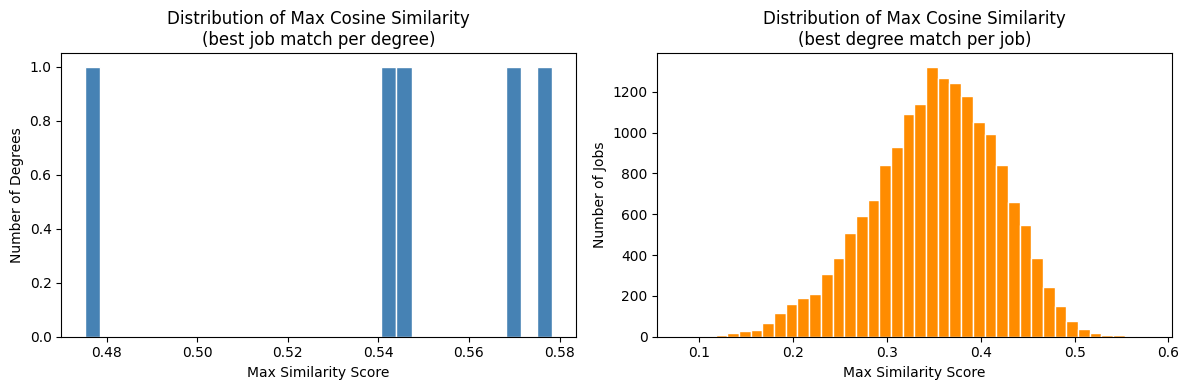

Degrees where best match > 0.5: 4 / 5


In [21]:
# Distribution of max similarity scores per degree (health check)
import matplotlib.pyplot as plt

max_sim_per_degree = sim_matrix.max(axis=1)
mean_sim_per_degree = sim_matrix.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(max_sim_per_degree, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Max Cosine Similarity\n(best job match per degree)')
axes[0].set_xlabel('Max Similarity Score')
axes[0].set_ylabel('Number of Degrees')

axes[1].hist(sim_matrix.max(axis=0), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution of Max Cosine Similarity\n(best degree match per job)')
axes[1].set_xlabel('Max Similarity Score')
axes[1].set_ylabel('Number of Jobs')

plt.tight_layout()
plt.savefig(CACHE_DIR / 'similarity_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Degrees where best match > 0.5: {(max_sim_per_degree > 0.5).sum()} / {len(degree_profiles)}')

---
## Section 5: Job-Skill Coverage Score (Hybrid Alignment)

We complement semantic similarity with an explicit job-skill coverage signal. The structured `skills[]` field in job ads provides a clean skill vocabulary. We match this against degree profile text lexically and score how much of each job's tagged skill set is covered.

In [22]:
# Build a global skill vocabulary from all job ads
all_skills = set()
for skill_list in jobs['skills']:
    if isinstance(skill_list, (list, tuple, set, np.ndarray, pd.Series)):
        all_skills.update(str(s).lower().strip() for s in skill_list if pd.notna(s) and str(s).strip())

print(f'Unique skills in job ads: {len(all_skills):,}')

# Sort by length descending to match longer phrases first
skill_vocab = sorted(all_skills, key=len, reverse=True)
print('Sample skills:', skill_vocab[:20])

Unique skills in job ads: 9,129
Sample skills: ['electrical engineering (including power engineerin', 'process unit and utilities operations  management', 'process unit and utilities operations management', 'geriatrics, specialist qualification (physician)', 'continuous integration and continuous deployment', 'workplace safety and health culture  development', 'process plant and equipment integrity management', 'workplace safety and health culture development', 'user interface and user experience optimisation', 'site and factory acceptance testing management', 'electrical and electronic systems  maintenance', 'learning and development programmes management', 'order processing and change request management', 'import and export documentation administration', 'children with speech and language difficulties', 'robotic and automation technology  application', 'food and beverage safety, hygiene and security', 'container loading and unloading administration', 'food and beverage quality audit 

In [23]:
def extract_skills_from_text(text: str, vocab: list[str]) -> set[str]:
    """Find which skills from vocab appear (case-insensitive, whole-word)."""
    text_lower = str(text).lower()
    found = set()

    for skill in vocab:
        pattern = r'\b' + re.escape(skill.lower()) + r'\b'
        if re.search(pattern, text_lower):
            found.add(skill)

    return found


def job_skill_coverage(degree_skills: set, job_skills: set) -> float:
    if not job_skills:
        return 0.0
    return len(degree_skills & job_skills) / len(job_skills)


print('Extracting skills from degree profiles...')
DEGREE_SKILLS_CACHE = CACHE_DIR / 'degree_skills_actual_degrees.json'

expected_ids = set(degree_profiles['degree_key'].astype(str))
degree_skills = {}
rebuild_cache = True

if DEGREE_SKILLS_CACHE.exists():
    with open(DEGREE_SKILLS_CACHE, 'r') as f:
        degree_skills_raw = json.load(f)

    cached_keys = set(degree_skills_raw.keys())

    if cached_keys == expected_ids:
        degree_skills = {k: set(v) for k, v in degree_skills_raw.items()}
        rebuild_cache = False
        print('Loaded from cache.')
    else:
        print('Cache keys do not match current degree_ids; rebuilding cache...')

if rebuild_cache:
    degree_skills = {}
    for _, row in tqdm(
        degree_profiles.iterrows(),
        total=len(degree_profiles),
        desc='Degree skill extraction'
    ):
        degree_key = str(row['degree_key'])
        degree_skills[degree_key] = extract_skills_from_text(row['profile_text'], skill_vocab)

    with open(DEGREE_SKILLS_CACHE, 'w') as f:
        json.dump({k: sorted(v) for k, v in degree_skills.items()}, f, indent=2)

    print(f'Cached degree skills to: {DEGREE_SKILLS_CACHE}')

# Show skills found for CS
cs_row = degree_profiles[degree_profiles['degree_id'] == 'cs']

if not cs_row.empty:
    degree_id = cs_row.iloc[0]['degree_key']
    degree_name = cs_row.iloc[0]['degree_name']
    print(f'\nSkills found in {degree_name} ({degree_id}):')
    print(sorted(degree_skills.get(degree_id, set()))[:30])
else:
    print('CS degree not found in degree_profiles.')

Extracting skills from degree profiles...
Loaded from cache.

Skills found in Computer Science (cs):
['able', 'algebra', 'algorithm design', 'algorithms', 'analysis', 'applications', 'architecture', 'articulate', 'artificial intelligence', 'artistic', 'arts', 'asian culture', 'assembly', 'authentication', 'automation', 'autonomous', 'basic', 'calculus', 'capital', 'case analysis', 'categorical data analysis', 'circuit design', 'cleaning', 'code', 'collaborative', 'communicate', 'communication', 'communication skills', 'community', 'components']


In [24]:
print(list(degree_skills.keys())[:10])

['biz', 'ce', 'cnm', 'cs', 'dsa']


In [25]:
SKILL_COVERAGE_CACHE = CACHE_DIR / f'skill_coverage_matrix_{JOB_CORPUS_VERSION}_{SKILL_SIGNAL_VERSION}.npy'
print(f'Skill coverage cache: {SKILL_COVERAGE_CACHE}')


Skill coverage cache: /Users/marcusyeo/Github/DSA4264-Text-Group-3/notebooks/cache/skill_coverage_matrix_targeted_dedup_v2_job_skill_coverage_v1.npy


In [26]:
# Job-skill coverage for each job's skill set against each degree's extracted skills
# Shape: (n_degrees × n_jobs)
SKILL_COVERAGE_CACHE = CACHE_DIR / f'skill_coverage_matrix_{JOB_CORPUS_VERSION}_{SKILL_SIGNAL_VERSION}.npy'
expected_shape = (len(degree_profiles), len(jobs))

rebuild_skill_coverage = True
if SKILL_COVERAGE_CACHE.exists():
    cached_skill_coverage = np.load(SKILL_COVERAGE_CACHE)
    if cached_skill_coverage.shape == expected_shape:
        print('Loading job-skill coverage matrix from cache...')
        skill_coverage_matrix = cached_skill_coverage
        rebuild_skill_coverage = False
    else:
        print('Cached skill coverage matrix does not match the current degree/job corpus; rebuilding...')

if rebuild_skill_coverage:
    print('Computing job-skill coverage matrix...')
    n_deg = len(degree_profiles)
    n_job = len(jobs)
    skill_coverage_matrix = np.zeros((n_deg, n_job), dtype=np.float32)

    # Pre-convert job skills to list-of-sets for speed
    job_skill_sets = [
        set(s.lower().strip() for s in row if s)
        for row in jobs['skills'].tolist()
    ]

    for d_idx, (_, d_row) in enumerate(tqdm(degree_profiles.iterrows(), total=n_deg, desc='Job-skill coverage')):
        d_skills = degree_skills.get(d_row['degree_key'], set())
        if not d_skills:
            continue
        for j_idx, j_skills in enumerate(job_skill_sets):
            skill_coverage_matrix[d_idx, j_idx] = job_skill_coverage(d_skills, j_skills)

    np.save(SKILL_COVERAGE_CACHE, skill_coverage_matrix)
    print(f'Saved skill coverage matrix → {SKILL_COVERAGE_CACHE}')

print(f'Skill coverage matrix shape: {skill_coverage_matrix.shape}')
print(f'Non-zero entries: {(skill_coverage_matrix > 0).sum():,}')


Loading job-skill coverage matrix from cache...
Skill coverage matrix shape: (5, 17346)
Non-zero entries: 46,171


In [27]:
# Hybrid alignment score: weighted combination
ALPHA = 0.7  # weight for semantic similarity
BETA  = 0.3  # weight for job-skill coverage

if sim_matrix.shape != skill_coverage_matrix.shape:
    raise ValueError(
        f'sim_matrix shape {sim_matrix.shape} does not match skill_coverage_matrix shape {skill_coverage_matrix.shape}. '
        'Re-run Sections 3-5 so both matrices are rebuilt from the same degree/job corpus.'
    )

hybrid_matrix = ALPHA * sim_matrix + BETA * skill_coverage_matrix
print(f'Hybrid score matrix shape: {hybrid_matrix.shape}')
print(f'Score range: [{hybrid_matrix.min():.4f}, {hybrid_matrix.max():.4f}]')

def top_k_jobs_hybrid(degree_idx: int, k: int = K) -> pd.DataFrame:
    """Return top-k jobs by hybrid alignment score for a given degree."""
    scores = hybrid_matrix[degree_idx]
    top_idx = np.argsort(scores)[::-1][:k]
    return pd.DataFrame({
        'rank'        : range(1, k+1),
        'job_id'      : jobs.iloc[top_idx]['job_id'].values,
        'job_title'   : jobs.iloc[top_idx]['title'].values,
        'categories'  : jobs.iloc[top_idx]['categories_str'].values,
        'cosine_sim'  : sim_matrix[degree_idx, top_idx].round(4),
        'skill_coverage': skill_coverage_matrix[degree_idx, top_idx].round(4),
        'hybrid_score': scores[top_idx].round(4),
    })

Hybrid score matrix shape: (5, 17346)
Score range: [0.0329, 0.5090]


In [28]:
# Compare baseline vs hybrid for Computer Science
cs_idx = degree_profiles[degree_profiles['degree_id'] == 'cs'].index

if len(cs_idx) > 0:
    idx = degree_profiles.index.get_loc(cs_idx[0])
    degree_name = degree_profiles.iloc[idx]['degree_name']
    print(f'=== Hybrid Top-{K} for {degree_name} (cs) ===')
    display(top_k_jobs_hybrid(idx, K))
else:
    print('No CS degree found — showing first degree profile instead.')
    display(top_k_jobs_hybrid(0, K))

=== Hybrid Top-10 for Computer Science (cs) ===


,rank,job_id,job_title,categories,cosine_sim,skill_coverage,hybrid_score
0,1,MCF-2026-0184617,"Research Assistant, School of Computing",Sciences / Laboratory / R&D,0.4355,0.5000,0.4549
1,2,MCF-2025-1390895,"Staff Software Engineer, Applied AI, Google De...",Information Technology,0.3102,0.7000,0.4271
2,3,MCF-2025-1787631,Software Engineer,"Engineering, Information Technology",0.3905,0.5000,0.4234
3,4,MCF-2025-1801982,Software Engineer (Precision / Automation),"Engineering, Information Technology, Manufactu...",0.4723,0.3077,0.4229
4,5,MCF-2025-1801975,Software Engineer (Semiconductor Industry),"Engineering, Information Technology, Manufactu...",0.4700,0.3077,0.4213
5,6,MCF-2026-0180974,"Software Engineer, Applied AI, Google DeepMind",Information Technology,0.3106,0.6000,0.3974
6,7,MCF-2026-0188162,Calypso Developer (Contract),Information Technology,0.4285,0.3000,0.3899
7,8,MCF-2026-0187901,Junior Software Engineer (Bank) l 12-month con...,Information Technology,0.4451,0.2500,0.3866
8,9,MCF-2026-0173982,"Research Scientist, Reasoning & AGI, Google De...",Information Technology,0.2947,0.6000,0.3863
9,10,MCF-2026-0190683,Software Application Engineer - WCAN,Information Technology,0.4629,0.2000,0.3840


In [29]:
# For Section 8:
HYBRID_MATRIX_CACHE = CACHE_DIR / f'hybrid_matrix_{JOB_CORPUS_VERSION}_{SEMANTIC_RETRIEVAL_VERSION}_{SKILL_SIGNAL_VERSION}.npy'
np.save(HYBRID_MATRIX_CACHE, hybrid_matrix)
print(f'Saved hybrid matrix to: {HYBRID_MATRIX_CACHE}')


Saved hybrid matrix to: /Users/marcusyeo/Github/DSA4264-Text-Group-3/notebooks/cache/hybrid_matrix_targeted_dedup_v2_module_top5_job120_v1_job_skill_coverage_v1.npy


---
## Section 6: Job Clustering (Scalability Layer)

Clustering the filtered, deduplicated in-scope job ads into role-level groups reduces sensitivity to firm-specific wording and provides MOE with a cleaner **degree ↔ job role category** view.


In [30]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.feature_extraction.text import TfidfVectorizer

N_CLUSTERS = 75  # adjust based on corpus size; 50–100 is a sensible range
CLUSTER_CACHE = CACHE_DIR / f'job_clusters_k{N_CLUSTERS}_{JOB_CORPUS_VERSION}.npy'

rebuild_clusters = True
if CLUSTER_CACHE.exists():
    cached_cluster_labels = np.load(CLUSTER_CACHE)
    if cached_cluster_labels.shape[0] == len(jobs):
        print('Loading cluster labels from cache...')
        cluster_labels = cached_cluster_labels
        rebuild_clusters = False
    else:
        print('Cached cluster labels do not match the current filtered job corpus; rebuilding...')

if rebuild_clusters:
    print(f'Clustering {len(jobs):,} jobs into {N_CLUSTERS} clusters...')
    t0 = time.time()
    kmeans = MiniBatchKMeans(
        n_clusters=N_CLUSTERS,
        random_state=42,
        batch_size=2048,
        n_init=5,
        max_iter=300,
    )
    cluster_labels = kmeans.fit_predict(job_embeddings)
    np.save(CLUSTER_CACHE, cluster_labels)
    print(f'Done in {time.time()-t0:.1f}s — inertia: {kmeans.inertia_:.1f}')

jobs['cluster_id'] = cluster_labels
print('Cluster size distribution:')
print(jobs['cluster_id'].value_counts().describe().round(0))


Loading cluster labels from cache...
Cluster size distribution:
count     75.0
mean     231.0
std      107.0
min       34.0
25%      162.0
50%      232.0
75%      294.0
max      543.0
Name: count, dtype: float64


In [31]:
# Label each cluster with its top TF-IDF terms and most common MCF category
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words='english', min_df=2)
tfidf.fit(jobs['description_clean'].tolist())
feature_names = np.array(tfidf.get_feature_names_out())

cluster_info = []
for c in range(N_CLUSTERS):
    mask = jobs['cluster_id'] == c
    cluster_jobs = jobs[mask]
    n = mask.sum()

    # Top TF-IDF terms
    vecs = tfidf.transform(cluster_jobs['description_clean'].tolist())
    mean_tfidf = np.asarray(vecs.mean(axis=0)).flatten()
    top_term_idx = mean_tfidf.argsort()[::-1][:8]
    top_terms = ', '.join(feature_names[top_term_idx])

    # Most common MCF category
    all_cats = [c for cats in cluster_jobs['categories'].tolist() for c in (cats if isinstance(cats, list) else [])]
    top_cat = pd.Series(all_cats).value_counts().index[0] if all_cats else 'Unknown'

    # Most common title words
    title_words = pd.Series(' '.join(cluster_jobs['title'].tolist()).lower().split()).value_counts()
    common_title = ', '.join(title_words.head(5).index.tolist())

    cluster_info.append({
        'cluster_id'   : c,
        'n_jobs'       : n,
        'top_category' : top_cat,
        'top_terms'    : top_terms,
        'common_titles': common_title,
    })

cluster_df = pd.DataFrame(cluster_info).sort_values('n_jobs', ascending=False)
print('Top 20 clusters by size:')
display(cluster_df.head(20))

Top 20 clusters by size:


,cluster_id,n_jobs,top_category,top_terms,common_titles
55,55,543,Accounting / Auditing / Taxation,"accounting, accounts, financial, tax, finance,...","accounts, executive, assistant, accountant, -"
3,3,451,F&B,"food, kitchen, chef, hygiene, dishes, menu, in...","chef, cook, assistant, kitchen, de"
9,9,407,Building and Construction,"project, site, construction, works, civil, eng...","engineer, project, site, manager, civil"
20,20,398,Logistics / Supply Chain,"warehouse, logistics, inventory, goods, operat...","warehouse, assistant, executive, logistics, /"
61,61,389,F&B,"restaurant, food, service, staff, customer, be...","manager, restaurant, supervisor, service, assi..."
41,41,389,Engineering,"engineering, design, process, manufacturing, m...","engineer, design, senior, process, product"
1,1,387,Engineering,"maintenance, equipment, repair, mechanical, wo...","technician, |, service, /, maintenance"
12,12,381,Sales / Retail,"ll, face, people, growth, fun, team, marketing...","marketing, events, sales, brand, &"
60,60,380,Sales / Retail,"sales, business, customer, market, new, relati...","sales, manager, executive, business, development"
27,27,360,Information Technology,"cloud, ai, aws, infrastructure, experience, se...","engineer, cloud, developer, ai, architect"


In [32]:
# Compute degree-to-cluster alignment matrix using cluster centroids
# Centroid = mean of unit-norm embeddings → re-normalise for cosine sim

cluster_centroids = np.zeros((N_CLUSTERS, job_embeddings.shape[1]), dtype=np.float32)
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    if mask.sum() > 0:
        centroid = job_embeddings[mask].mean(axis=0)
        norm = np.linalg.norm(centroid)
        cluster_centroids[c] = centroid / norm if norm > 0 else centroid

# degree-cluster similarity: (n_degrees × n_clusters)
module_cluster_sim = module_embeddings @ cluster_centroids.T
degree_cluster_sim = np.zeros((len(degree_profiles), N_CLUSTERS), dtype=np.float32)

for d_idx, degree_key in enumerate(degree_profiles['degree_key'].tolist()):
    module_idx = degree_module_indices.get(degree_key, np.array([], dtype=int))
    degree_cluster_sim[d_idx] = aggregate_top_k_similarity(module_cluster_sim[module_idx], DEGREE_MODULE_TOP_K)

print(f'Degree-cluster similarity matrix: {degree_cluster_sim.shape}')

Degree-cluster similarity matrix: (5, 75)


In [33]:
# Build a labelled degree-cluster alignment table
cluster_label_map = dict(zip(cluster_df['cluster_id'], cluster_df['top_category']))
cluster_terms_map = dict(zip(cluster_df['cluster_id'], cluster_df['top_terms']))

alignment_rows = []

for d_idx, d_row in degree_profiles.iterrows():
    d_pos = degree_profiles.index.get_loc(d_idx)
    scores = degree_cluster_sim[d_pos]
    top_clusters = np.argsort(scores)[::-1][:5]

    for rank, c_id in enumerate(top_clusters, 1):
        alignment_rows.append({
            'degree_id'      : d_row['degree_id'],
            'degree'         : d_row['degree_name'],
            'rank'           : rank,
            'cluster_id'     : int(c_id),
            'cluster_label'  : cluster_label_map.get(int(c_id), f'Cluster {c_id}'),
            'cluster_terms'  : cluster_terms_map.get(int(c_id), ''),
            'sim_score'      : round(float(scores[c_id]), 4),
        })


alignment_table = pd.DataFrame(alignment_rows)
alignment_table.to_csv(CACHE_DIR / 'degree_cluster_alignment.csv', index=False)

print('Sample: top-3 cluster matches per degree')
display(alignment_table[alignment_table['rank'] <= 3])

Sample: top-3 cluster matches per degree


,degree_id,degree,rank,cluster_id,cluster_label,cluster_terms,sim_score
0,biz,Business Administration,1,2,Banking and Finance,"financial, finance, bank, accounting, banking,...",0.5471
1,biz,Business Administration,2,34,Banking and Finance,"investment, financial, client, wealth, risk, b...",0.5383
2,biz,Business Administration,3,60,Sales / Retail,"sales, business, customer, market, new, relati...",0.5364
5,ce,Civil Engineering,1,9,Building and Construction,"project, site, construction, works, civil, eng...",0.5101
6,ce,Civil Engineering,2,41,Engineering,"engineering, design, process, manufacturing, m...",0.4663
7,ce,Civil Engineering,3,43,Design,"design, creative, visual, 3d, production, adob...",0.4642
10,cnm,Communications and New Media,1,48,Marketing / Public Relations,"content, media, social, social media, marketin...",0.5538
11,cnm,Communications and New Media,2,43,Design,"design, creative, visual, 3d, production, adob...",0.4968
12,cnm,Communications and New Media,3,7,Education and Training,"students, singapore, student, training, recrui...",0.4844
15,cs,Computer Science,1,32,Information Technology,"software, development, experience, design, tec...",0.4628


In [34]:
# For Section 8:
CLUSTER_DF_CACHE = CACHE_DIR / f'cluster_df_{JOB_CORPUS_VERSION}.csv'
DEGREE_CLUSTER_SIM_CACHE = CACHE_DIR / f'degree_cluster_sim_{JOB_CORPUS_VERSION}_{SEMANTIC_RETRIEVAL_VERSION}.npy'

cluster_df.to_csv(CLUSTER_DF_CACHE, index=False)
np.save(DEGREE_CLUSTER_SIM_CACHE, degree_cluster_sim)
print(f'Saved cluster labels to: {CLUSTER_DF_CACHE}')
print(f'Saved degree-cluster similarity to: {DEGREE_CLUSTER_SIM_CACHE}')


Saved cluster labels to: /Users/marcusyeo/Github/DSA4264-Text-Group-3/notebooks/cache/cluster_df_targeted_dedup_v2.csv
Saved degree-cluster similarity to: /Users/marcusyeo/Github/DSA4264-Text-Group-3/notebooks/cache/degree_cluster_sim_targeted_dedup_v2_module_top5_job120_v1.npy


---
## Section 7: Gold Dataset and Evaluation

This section uses the project gold dataset stored in `notebooks/evaluation/gold_degree_job_alignment.csv` as the single evaluation source.

Every methodology is evaluated against the **same labelled degree-job pairs** so the comparison reflects alignment with human judgement rather than raw score scale alone.


### Notebook review summary

Key workflow fixes made in this notebook revision:

- Fixed a syntax error in the degree-module merge section so the notebook executes top to bottom.
- Made transformer loading lazy so cached embeddings can be reused without forcing a model download.
- Replaced the earlier manual placeholder evaluation with a shared framework that loads the project gold dataset directly.
- Standardised evaluation around the actual retrieval unit used in this notebook: **degree-profile to job** alignment.
- Deprecated the earlier standalone NDCG-only reporting and overlapping summary cells in favour of one consistent comparison table, plots, and agreement analysis.
- Evaluated the clustering layer as a **cluster-routed semantic ranker** so it can be compared fairly against other job-level retrieval methods.


In [ ]:
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import spearmanr
from sklearn.feature_extraction.text import TfidfVectorizer

N_CLUSTERS = int(globals().get('N_CLUSTERS', 75))

DEGREE_META_CACHE = CACHE_DIR / 'degree_profiles.parquet'
JOB_META_CACHE = CACHE_DIR / f'jobs_clean_{JOB_CORPUS_VERSION}.parquet'
SIM_MATRIX_CACHE = CACHE_DIR / f'sim_matrix_{MODEL_NAME.replace("/","_")}_{JOB_CORPUS_VERSION}_{SEMANTIC_RETRIEVAL_VERSION}.npy'
SKILL_COVERAGE_CACHE = CACHE_DIR / f'skill_coverage_matrix_{JOB_CORPUS_VERSION}_{SKILL_SIGNAL_VERSION}.npy'
HYBRID_MATRIX_CACHE = CACHE_DIR / f'hybrid_matrix_{JOB_CORPUS_VERSION}_{SEMANTIC_RETRIEVAL_VERSION}_{SKILL_SIGNAL_VERSION}.npy'
CLUSTER_CACHE = CACHE_DIR / f'job_clusters_k{N_CLUSTERS}_{JOB_CORPUS_VERSION}.npy'
DEGREE_CLUSTER_SIM_CACHE = CACHE_DIR / f'degree_cluster_sim_{JOB_CORPUS_VERSION}_{SEMANTIC_RETRIEVAL_VERSION}.npy'
LEXICAL_MATRIX_CACHE = CACHE_DIR / f'lexical_tfidf_matrix_{JOB_CORPUS_VERSION}.npy'
GOLD_DATASET_PATH = EVAL_DIR / 'gold_degree_job_alignment.csv'
METHOD_METRICS_PATH = EVAL_DIR / 'method_metrics.csv'
METHOD_QUERY_METRICS_PATH = EVAL_DIR / 'method_query_metrics.csv'

# Reload cached artefacts when running the notebook from this section after a restart.
if 'degree_profiles' not in globals():
    degree_profiles = pd.read_parquet(DEGREE_META_CACHE)
if 'jobs' not in globals():
    jobs = pd.read_parquet(JOB_META_CACHE)
if 'sim_matrix' not in globals():
    sim_matrix = np.load(SIM_MATRIX_CACHE)
if 'skill_coverage_matrix' not in globals():
    skill_coverage_matrix = np.load(SKILL_COVERAGE_CACHE)
if 'hybrid_matrix' not in globals():
    hybrid_matrix = np.load(HYBRID_MATRIX_CACHE)
if 'degree_cluster_sim' not in globals():
    degree_cluster_sim = np.load(DEGREE_CLUSTER_SIM_CACHE)
if 'cluster_labels' not in globals():
    cluster_labels = np.load(CLUSTER_CACHE)

jobs = jobs.copy()
degree_profiles = degree_profiles.copy()

if 'job_text' not in jobs.columns:
    jobs['job_text'] = jobs.apply(build_structured_job_text, axis=1)

jobs['cluster_id'] = np.asarray(cluster_labels, dtype=int)

expected_shape = (len(degree_profiles), len(jobs))
for name, matrix in {
    'sim_matrix': sim_matrix,
    'skill_coverage_matrix': skill_coverage_matrix,
    'hybrid_matrix': hybrid_matrix,
}.items():
    if matrix.shape != expected_shape:
        raise ValueError(f'{name} has shape {matrix.shape}, expected {expected_shape}. Re-run the upstream sections.')

if degree_cluster_sim.shape[0] != len(degree_profiles):
    raise ValueError('degree_cluster_sim does not match current degree_profiles. Re-run Section 6.')

if LEXICAL_MATRIX_CACHE.exists():
    lexical_matrix = np.load(LEXICAL_MATRIX_CACHE)
    if lexical_matrix.shape != expected_shape:
        lexical_matrix = None
else:
    lexical_matrix = None

if lexical_matrix is None:
    print('Building lexical TF-IDF baseline matrix...')
    lexical_vectorizer = TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2,
        max_features=30000,
    )
    corpus = degree_profiles['profile_text'].tolist() + jobs['job_text'].tolist()
    lexical_vectorizer.fit(corpus)
    degree_tfidf = lexical_vectorizer.transform(degree_profiles['profile_text'].tolist())
    job_tfidf = lexical_vectorizer.transform(jobs['job_text'].tolist())
    lexical_matrix = (degree_tfidf @ job_tfidf.T).toarray().astype(np.float32)
    np.save(LEXICAL_MATRIX_CACHE, lexical_matrix)
    print(f'Saved lexical baseline to: {LEXICAL_MATRIX_CACHE}')
else:
    print(f'Loaded lexical baseline from: {LEXICAL_MATRIX_CACHE}')

cluster_prior_matrix = degree_cluster_sim[:, jobs['cluster_id'].to_numpy()]
cluster_routed_matrix = (0.65 * cluster_prior_matrix + 0.35 * sim_matrix).astype(np.float32)


def slugify(text: str) -> str:
    return re.sub(r'[^a-z0-9]+', '_', text.lower()).strip('_')


method_score_matrices = {
    'Lexical TF-IDF': lexical_matrix,
    'Semantic cosine': sim_matrix,
    'Skill coverage': skill_coverage_matrix,
    'Hybrid semantic + skill': hybrid_matrix,
    'Cluster-routed semantic': cluster_routed_matrix,
}

method_notes = {
    'Lexical TF-IDF': 'Sparse lexical baseline over curriculum and job text.',
    'Semantic cosine': f'Degree-to-job cosine using top-{DEGREE_MODULE_TOP_K} module similarities.',
    'Skill coverage': 'Exact overlap between extracted degree skills and tagged job skills.',
    'Hybrid semantic + skill': f'Weighted blend with alpha={ALPHA:.1f}, beta={BETA:.1f}.',
    'Cluster-routed semantic': 'Cluster prior from Section 6 combined with semantic job scores.',
}

def normalise_text(value) -> str:
    return '' if pd.isna(value) else str(value).strip()


degree_profiles['degree_lookup_id'] = degree_profiles['degree_id'].map(normalise_text)
degree_profiles['degree_lookup_name'] = degree_profiles['degree_name'].map(normalise_text)
jobs['job_lookup_id'] = jobs['job_id'].map(normalise_text)

degree_pair_index = {
    (row.degree_lookup_id, row.degree_lookup_name): idx
    for idx, row in enumerate(degree_profiles[['degree_lookup_id', 'degree_lookup_name']].itertuples(index=False))
}
degree_id_index = degree_profiles.groupby('degree_lookup_id').indices
degree_name_index = degree_profiles.groupby('degree_lookup_name').indices
job_index = {job_id: idx for idx, job_id in enumerate(jobs['job_lookup_id'])}


def resolve_degree_profile_idx(degree_id: str, degree_name: str):
    degree_id = normalise_text(degree_id)
    degree_name = normalise_text(degree_name)
    pair_key = (degree_id, degree_name)
    if pair_key in degree_pair_index:
        return int(degree_pair_index[pair_key])

    id_matches = degree_id_index.get(degree_id, [])
    if len(id_matches) == 1:
        return int(id_matches[0])

    name_matches = degree_name_index.get(degree_name, [])
    if len(name_matches) == 1:
        return int(name_matches[0])

    return None

print('Methods available for evaluation:')
for method_name in method_score_matrices:
    print(f'  - {method_name}')


### 7a - Gold Dataset Loading

The notebook now loads the project gold dataset directly from `notebooks/evaluation/gold_degree_job_alignment.csv`.

Expected labels:

- `Relevant = 2`
- `Somewhat Relevant = 1`
- `Not Relevant = 0`

Any extra provenance columns in the CSV are ignored for evaluation so the notebook focuses on the final human judgement labels.


In [ ]:
LABEL_TO_SCORE = {
    'Relevant': 2,
    'Somewhat Relevant': 1,
    'Not Relevant': 0,
}
SCORE_TO_LABEL = {score: label for label, score in LABEL_TO_SCORE.items()}

if not GOLD_DATASET_PATH.exists():
    raise FileNotFoundError(
        f'Gold dataset not found at {GOLD_DATASET_PATH}. Place gold_degree_job_alignment.csv in notebooks/evaluation.'
    )


def standardise_gold_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if 'degree_id' not in df.columns and 'curriculum_id' in df.columns:
        df['degree_id'] = df['curriculum_id']
    if 'degree_name' not in df.columns and 'curriculum_title' in df.columns:
        df['degree_name'] = df['curriculum_title']

    if 'human_relevance_score' not in df.columns:
        if 'human_label' not in df.columns:
            raise ValueError('Gold dataset must contain either human_relevance_score or human_label.')
        raw_labels = df['human_label'].astype(str).str.strip().str.lower()
        df['human_relevance_score'] = raw_labels.map({
            '2': 2,
            '1': 1,
            '0': 0,
            'relevant': 2,
            'somewhat relevant': 1,
            'not relevant': 0,
        })

    df['human_relevance_score'] = pd.to_numeric(df['human_relevance_score'], errors='coerce')
    df = df[df['human_relevance_score'].isin([0, 1, 2])].copy()
    df['human_relevance_score'] = df['human_relevance_score'].astype(int)
    df['human_label'] = df['human_relevance_score'].map(SCORE_TO_LABEL)
    df['degree_id'] = df['degree_id'].map(normalise_text)
    df['degree_name'] = df['degree_name'].map(normalise_text)
    df['job_id'] = df['job_id'].map(normalise_text)

    if 'query_id' not in df.columns:
        df['query_id'] = df['degree_id']
    if 'curriculum_id' not in df.columns:
        df['curriculum_id'] = df['degree_id']
    if 'curriculum_title' not in df.columns:
        df['curriculum_title'] = df['degree_name']
    if 'job_title' not in df.columns:
        df = df.merge(jobs[['job_id', 'title']], on='job_id', how='left')
        df = df.rename(columns={'title': 'job_title'})

    keep_first_non_missing = {
        'job_categories': jobs[['job_id', 'categories_str']].rename(columns={'categories_str': 'job_categories'}),
        'job_text': jobs[['job_id', 'job_text']],
        'company': jobs[['job_id', 'company']],
    }
    for col, lookup in keep_first_non_missing.items():
        if col not in df.columns or df[col].isna().any():
            df = df.drop(columns=[col], errors='ignore').merge(lookup, on='job_id', how='left')

    return df


gold_raw_df = pd.read_csv(GOLD_DATASET_PATH)
gold_df = standardise_gold_dataset(gold_raw_df)
gold_df['degree_profile_idx'] = gold_df.apply(
    lambda row: resolve_degree_profile_idx(row['degree_id'], row['degree_name']),
    axis=1,
)
gold_df['job_lookup_id'] = gold_df['job_id'].map(normalise_text)
gold_df['job_idx'] = gold_df['job_lookup_id'].map(job_index)

gold_eval_df = gold_df[
    gold_df['degree_profile_idx'].notna() & gold_df['job_idx'].notna()
].copy()
gold_eval_df['degree_profile_idx'] = gold_eval_df['degree_profile_idx'].astype(int)
gold_eval_df['job_idx'] = gold_eval_df['job_idx'].astype(int)

skipped_gold_df = gold_df.loc[gold_df.index.difference(gold_eval_df.index)].copy()
if gold_eval_df.empty:
    raise ValueError('No gold rows could be matched to the current degree/job artefacts. Re-run the upstream sections.')

gold_preview_cols = [
    'degree_id', 'degree_name', 'job_id', 'job_title', 'human_label', 'human_relevance_score'
]
label_distribution = (
    gold_eval_df['human_label']
    .value_counts()
    .rename_axis('human_label')
    .reset_index(name='count')
)
gold_load_summary = pd.DataFrame([
    {
        'loaded_rows': len(gold_df),
        'matched_rows': len(gold_eval_df),
        'skipped_rows': len(skipped_gold_df),
        'matched_degrees': gold_eval_df[['degree_id', 'degree_name']].drop_duplicates().shape[0],
        'skipped_degrees': skipped_gold_df[['degree_id', 'degree_name']].drop_duplicates().shape[0],
    }
])

display(Markdown(f'**Loaded gold dataset:** `{GOLD_DATASET_PATH}`'))
display(gold_load_summary)
if not skipped_gold_df.empty:
    display(Markdown('**Skipped gold pairs (unmatched to current cached artefacts):**'))
    display(skipped_gold_df[['degree_id', 'degree_name']].drop_duplicates().sort_values(['degree_id', 'degree_name']))
display(label_distribution)
display(gold_eval_df[gold_preview_cols].head(10))


### 7b - Metric Definitions and Consistent Method Comparison

The comparison below evaluates each method on the **same gold-labelled degree-job pairs**.

Metrics:

- `Precision@k` (strict): fraction of the top-`k` jobs labelled **Relevant (2)**.
- `RelaxedPrecision@k`: fraction of the top-`k` jobs labelled **Relevant or Somewhat Relevant (>=1)**.
- `HitRate@k` (strict): whether at least one **Relevant (2)** job appears in the top-`k`.
- `RelaxedHitRate@k`: whether at least one job with score `>=1` appears in the top-`k`.
- `Human-model agreement`: mean **query-wise Spearman rank correlation** between model scores and gold relevance scores. This is appropriate here because all methods produce ranked job scores rather than discrete class labels.


In [38]:
def precision_at_k(labels: list[int], k: int, threshold: int = 2) -> float:
    top_labels = labels[:k]
    if not top_labels:
        return 0.0
    return float(np.mean([label >= threshold for label in top_labels]))


def hit_rate_at_k(labels: list[int], k: int, threshold: int = 2) -> float:
    top_labels = labels[:k]
    if not top_labels:
        return 0.0
    return float(any(label >= threshold for label in top_labels))


def safe_spearman(scores: np.ndarray, labels: np.ndarray) -> float:
    if len(scores) < 2:
        return np.nan
    if np.unique(scores).size < 2 or np.unique(labels).size < 2:
        return np.nan
    rho, _ = spearmanr(scores, labels)
    return float(rho) if pd.notna(rho) else np.nan


ks = (1, 3, 5)
query_metric_rows = []
comparison_rows = []

for method_name, score_matrix in method_score_matrices.items():
    per_query_rows = []
    combined_scores = []
    combined_labels = []

    for degree_profile_idx, grp in gold_eval_df.groupby('degree_profile_idx'):
        d_idx = int(degree_profile_idx)
        eval_grp = grp.copy()

        eval_grp['model_score'] = eval_grp['job_lookup_id'].map(
            lambda job_id: float(score_matrix[d_idx, job_index[job_id]])
        )
        eval_grp = eval_grp.sort_values('model_score', ascending=False).reset_index(drop=True)

        labels = eval_grp['human_relevance_score'].astype(int).tolist()
        scores = eval_grp['model_score'].to_numpy(dtype=float)
        gold_scores = eval_grp['human_relevance_score'].to_numpy(dtype=float)
        agreement = safe_spearman(scores, gold_scores)

        row = {
            'degree_profile_idx': d_idx,
            'degree_id': eval_grp['degree_id'].iloc[0],
            'degree_name': eval_grp['degree_name'].iloc[0],
            'method': method_name,
            'gold_pairs': len(eval_grp),
            'Human-model agreement': agreement,
        }

        for k in ks:
            row[f'Precision@{k}'] = precision_at_k(labels, k, threshold=2)
            row[f'HitRate@{k}'] = hit_rate_at_k(labels, k, threshold=2)
            row[f'RelaxedPrecision@{k}'] = precision_at_k(labels, k, threshold=1)
            row[f'RelaxedHitRate@{k}'] = hit_rate_at_k(labels, k, threshold=1)

        per_query_rows.append(row)
        combined_scores.extend(scores.tolist())
        combined_labels.extend(gold_scores.tolist())

    method_query_df = pd.DataFrame(per_query_rows)
    query_metric_rows.append(method_query_df)

    summary_row = {
        'Method': method_name,
        'Notes': method_notes[method_name],
        'GoldPairs': int(method_query_df['gold_pairs'].sum()) if not method_query_df.empty else 0,
        'Degrees': int(method_query_df['degree_profile_idx'].nunique()) if not method_query_df.empty else 0,
        'Global agreement': safe_spearman(np.asarray(combined_scores), np.asarray(combined_labels)),
    }

    for metric in [
        'Precision@1', 'Precision@3', 'Precision@5',
        'HitRate@1', 'HitRate@3', 'HitRate@5',
        'RelaxedPrecision@1', 'RelaxedPrecision@3', 'RelaxedPrecision@5',
        'RelaxedHitRate@1', 'RelaxedHitRate@3', 'RelaxedHitRate@5',
        'Human-model agreement',
    ]:
        summary_row[metric] = float(method_query_df[metric].mean()) if metric in method_query_df else np.nan

    comparison_rows.append(summary_row)

query_metrics_df = pd.concat(query_metric_rows, ignore_index=True)
comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ['Human-model agreement', 'Precision@3', 'HitRate@3'],
    ascending=False,
).reset_index(drop=True)

comparison_df.to_csv(METHOD_METRICS_PATH, index=False)
query_metrics_df.to_csv(METHOD_QUERY_METRICS_PATH, index=False)

strict_columns = [
    'Method', 'Precision@1', 'Precision@3', 'Precision@5',
    'HitRate@1', 'HitRate@3', 'HitRate@5',
    'Human-model agreement', 'Notes'
]
relaxed_columns = [
    'Method', 'RelaxedPrecision@1', 'RelaxedPrecision@3', 'RelaxedPrecision@5',
    'RelaxedHitRate@1', 'RelaxedHitRate@3', 'RelaxedHitRate@5'
]

print(f'Saved method comparison to: {METHOD_METRICS_PATH}')
print(f'Saved query-level metrics to: {METHOD_QUERY_METRICS_PATH}')
display(comparison_df[strict_columns].round(3))
display(comparison_df[relaxed_columns].round(3))


Saved method comparison to: /Users/marcusyeo/Github/DSA4264-Text-Group-3/notebooks/evaluation/method_metrics.csv
Saved query-level metrics to: /Users/marcusyeo/Github/DSA4264-Text-Group-3/notebooks/evaluation/method_query_metrics.csv


,Method,Precision@1,Precision@3,Precision@5,HitRate@1,HitRate@3,HitRate@5,Human-model agreement,Notes
0,Cluster-routed semantic,1.0,1.000,1.00,1.0,1.0,1.0,0.620,Cluster prior from Section 6 combined with sem...
1,Hybrid semantic + skill,1.0,1.000,1.00,1.0,1.0,1.0,0.615,"Weighted blend with alpha=0.7, beta=0.3."
2,Semantic cosine,1.0,1.000,0.92,1.0,1.0,1.0,0.603,Degree-to-job cosine using top-5 module simila...
3,Skill coverage,1.0,0.933,0.92,1.0,1.0,1.0,0.508,Exact overlap between extracted degree skills ...
4,Lexical TF-IDF,0.8,0.867,0.80,0.8,1.0,1.0,0.419,Sparse lexical baseline over curriculum and jo...


,Method,RelaxedPrecision@1,RelaxedPrecision@3,RelaxedPrecision@5,RelaxedHitRate@1,RelaxedHitRate@3,RelaxedHitRate@5
0,Cluster-routed semantic,1.0,1.000,1.00,1.0,1.0,1.0
1,Hybrid semantic + skill,1.0,1.000,1.00,1.0,1.0,1.0
2,Semantic cosine,1.0,1.000,1.00,1.0,1.0,1.0
3,Skill coverage,1.0,1.000,1.00,1.0,1.0,1.0
4,Lexical TF-IDF,0.8,0.933,0.96,0.8,1.0,1.0


### 7c - Plots and Diagnostic Tables

The charts below focus on the project objective: **which matching methodology aligns most closely with the reference labels**.


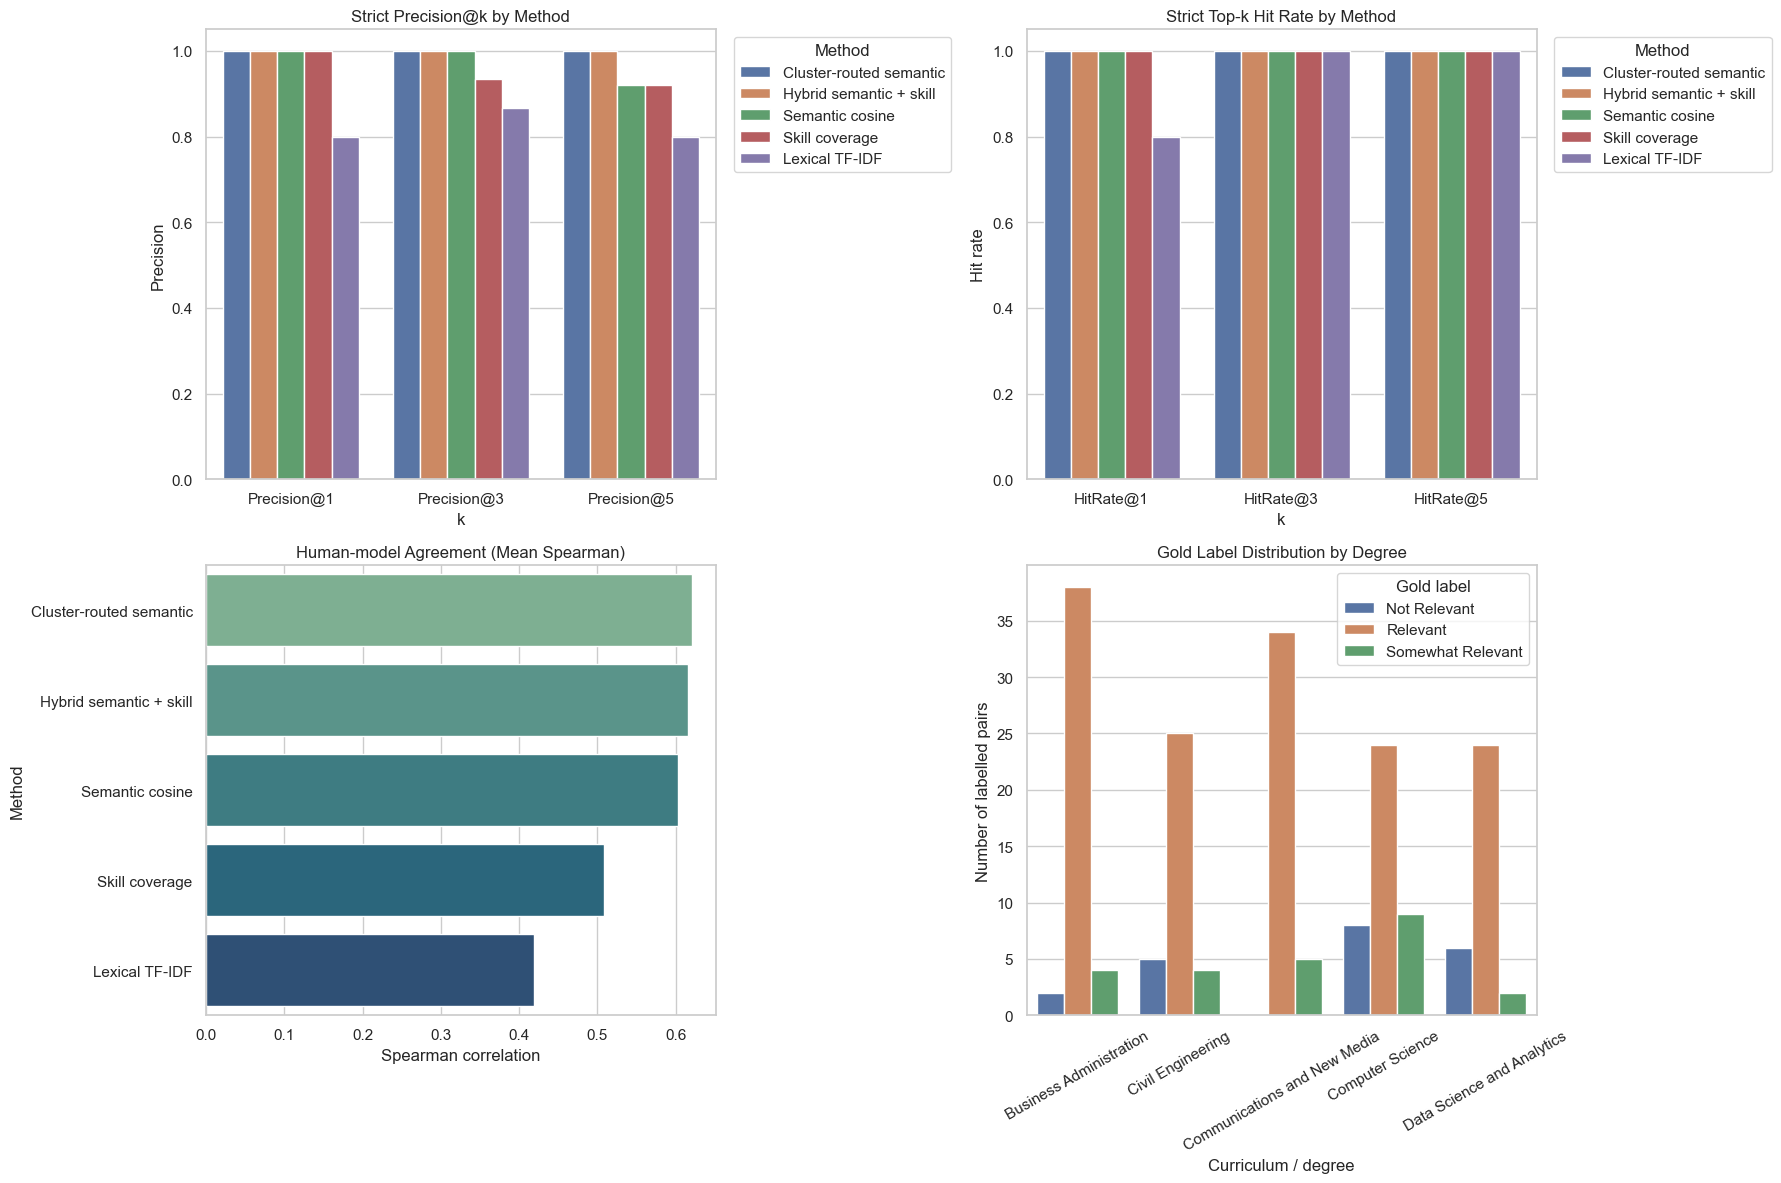

In [39]:
sns.set_theme(style='whitegrid', context='notebook')

precision_plot_df = comparison_df.melt(
    id_vars=['Method'],
    value_vars=['Precision@1', 'Precision@3', 'Precision@5'],
    var_name='Metric',
    value_name='Score',
)

hitrate_plot_df = comparison_df.melt(
    id_vars=['Method'],
    value_vars=['HitRate@1', 'HitRate@3', 'HitRate@5'],
    var_name='Metric',
    value_name='Score',
)

agreement_plot_df = comparison_df[['Method', 'Human-model agreement']].copy()
label_plot_df = (
    gold_eval_df.groupby(['degree_name', 'human_label'])
    .size()
    .reset_index(name='count')
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(data=precision_plot_df, x='Metric', y='Score', hue='Method', ax=axes[0, 0])
axes[0, 0].set_title('Strict Precision@k by Method')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.barplot(data=hitrate_plot_df, x='Metric', y='Score', hue='Method', ax=axes[0, 1])
axes[0, 1].set_title('Strict Top-k Hit Rate by Method')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Hit rate')
axes[0, 1].legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.barplot(data=agreement_plot_df, x='Human-model agreement', y='Method', palette='crest', ax=axes[1, 0])
axes[1, 0].set_title('Human-model Agreement (Mean Spearman)')
axes[1, 0].set_xlabel('Spearman correlation')
axes[1, 0].set_ylabel('Method')

sns.barplot(data=label_plot_df, x='degree_name', y='count', hue='human_label', ax=axes[1, 1])
axes[1, 1].set_title('Gold Label Distribution by Degree')
axes[1, 1].set_xlabel('Curriculum / degree')
axes[1, 1].set_ylabel('Number of labelled pairs')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].legend(title='Gold label')

plt.tight_layout()
plt.show()


---
## Section 8: Interpretation and Final Takeaway

This final section summarises which methodology aligns best with the loaded gold dataset and what the remaining methodological caveats are.


In [40]:
agreement_by_degree = (
    query_metrics_df
    .pivot_table(
        index=['degree_id', 'degree_name'],
        columns='method',
        values='Human-model agreement',
        aggfunc='mean',
    )
    .round(3)
)

precision_by_degree = (
    query_metrics_df
    .pivot_table(
        index=['degree_id', 'degree_name'],
        columns='method',
        values='Precision@3',
        aggfunc='mean',
    )
    .round(3)
)

print('Query-wise agreement by degree')
display(agreement_by_degree)

print('Query-wise Precision@3 by degree')
display(precision_by_degree)


Query-wise agreement by degree


,method,Cluster-routed semantic,Hybrid semantic + skill,Lexical TF-IDF,Semantic cosine,Skill coverage
degree_id,degree_name,,,,,
biz,Business Administration,0.414,0.433,0.084,0.439,0.260
ce,Civil Engineering,0.735,0.761,0.286,0.715,0.767
cnm,Communications and New Media,0.552,0.545,0.566,0.545,0.564
cs,Computer Science,0.707,0.637,0.508,0.617,0.362
dsa,Data Science and Analytics,0.693,0.699,0.649,0.699,0.589


Query-wise Precision@3 by degree


,method,Cluster-routed semantic,Hybrid semantic + skill,Lexical TF-IDF,Semantic cosine,Skill coverage
degree_id,degree_name,,,,,
biz,Business Administration,1.0,1.0,0.667,1.0,1.000
ce,Civil Engineering,1.0,1.0,0.667,1.0,1.000
cnm,Communications and New Media,1.0,1.0,1.000,1.0,1.000
cs,Computer Science,1.0,1.0,1.000,1.0,0.667
dsa,Data Science and Analytics,1.0,1.0,1.000,1.0,1.000


### Final takeaway

The framework should be judged by whether it can **reproduce human relevance judgements at scale**, not by making broad claims about whether any curriculum is inherently good or bad.


In [ ]:
best_method = comparison_df.sort_values(
    ['Human-model agreement', 'Precision@3', 'HitRate@3'],
    ascending=False,
).iloc[0]

summary_md = f"""
Using the gold dataset loaded from **`gold_degree_job_alignment.csv`**, **{best_method['Method']}** is the strongest overall method in this notebook.

- Mean `Precision@3`: `{best_method['Precision@3']:.3f}`
- Mean `HitRate@3`: `{best_method['HitRate@3']:.3f}`
- Mean query-wise Spearman agreement: `{best_method['Human-model agreement']:.3f}`

The key result is not just the winning method, but that every method is now evaluated on the **same labelled degree-job pairs**, so the comparison is about **alignment with human judgement** rather than raw retrieval score alone.

Main limitations:

- The current gold dataset should still be expanded over time to cover more degrees, more difficult borderline cases, and additional annotators.
- The clustering method is evaluated as a **cluster-routed job ranker**, which is the fairest job-level interpretation of the scalability layer but is still an approximation.
- Stronger substantive claims about curriculum-job fit should rely on repeated annotation rounds and inter-annotator agreement checks.
"""

display(Markdown(summary_md))
